**Re-executed 2026-07-25 under flopscope 0.9.1 (PR150 merged) + whestbench 0.13.0; this notebook documents the #14 two-ended-layer-30-refinement era estimator — analyzed bytes: `.nb_history_bytes/14_two_ended_layer30_refinement.py` (= git `7d8416a:examples/14_two_ended_layer30_refinement.py`); the §2b comparison uses `.nb_history_bytes/13_sobol_active_set_fold.py` (same pinned commit).**

Fixes applied on re-run: the #13/#14 example files were deleted from `examples/` at HEAD (commit `01123e7`), so the setup cell materializes the pinned bytes from git history into `.nb_history_bytes/`; the prediction caches (`.est14_error_cache.npz`, `.pred13_cache.npz`, `.mlp_lastvar_cache.npz`) were absent and are regenerated under the current environment (the era estimators use fixed N=40960 and ignore their budget argument, so PR150 repricing does not change predictions); §11's `examples/15_adaptive_budget_fold.py` bytes were never committed to git and are unrecoverable — its two code cells are tagged `skip-execution` and retain their 2026-07-05 recorded outputs (see the note there); every figure is stamped with the exact net sample (aicrowd/arc-whestbench-public-2026, v1-phase1, mini split, nets 0–99).

# Where does `14_two_ended_layer30_refinement.py` win, and where does its error come from?

An error-attribution study of the **current best submission family** (`examples/14_two_ended_layer30_refinement.py`,
after submission 314957) on the 100 public *mini* MLPs (`hf://aicrowd/arc-whestbench-public-2026@v1-phase1`).

**What the estimator does** (recap). It predicts each network's per-layer mean activations `(32, 256)`
by mixing closed-form analytics with a cheap, variance-reduced Monte-Carlo pass:

1. **Analytic classification** — diagonal mean/variance propagation gives each neuron
   `α = μ/σ`; classify **dead** (`α < -3`), **always-on** (`α > 3`), or **kink** (in between).
2. **Sobol QMC + antithetic** — 40 960 effective quasi-random samples pushed only through the
   non-dead ("active") sub-network.
3. **Layer fold (30–31)** — always-on neurons are linear, so their contribution is computed
   in closed form (`E[relu(z)] = E[z]`) and folded through the last weight matrix instead of sampled.
4. **Two-ended pilot refinement (NEW vs `#13`)** — a 5% pilot (reusing the same samples) re-checks *borderline*
   Stage-1 labels at layers 29–30: **promote** borderline-dead neurons (α∈[−4,−3]) back to kink, and **demote**
   borderline always-on neurons (α∈[3,4]) back to kink — so near-boundary neurons get *sampled* rather than
   zeroed or folded. Only the probe matmuls cost extra; the pilot rows are reused.
5. **Exact layer-0** (`E[relu(xᵀw)] = ‖w‖/√(2π)`) and **dead-neuron correction** (analytic `E[relu]`, not 0).

*Note:* the refinement touches layers **29–30 only**; the **last-layer (31) classification is the plain analytic
one**, so the class labels used throughout (dead/kink/on at the output) are identical to `#13`'s — but the last-layer
*predictions* differ because the refined penultimate means feed the final fold.

**What is scored.** `score = final_layer_MSE × budget_multiplier`. Only the **last layer** counts,
so this notebook centres on last-layer error, using the intermediate layers to explain how it arises.

**Questions.** (1) How good is it, and vs. what baselines? (2) Which *layers* introduce error?
(3) Which *neurons* — by class, magnitude, firing rate — carry the error? (4) Is the residual
**systematic bias** (learnable/correctable) or **irreducible variance**? (5) Does the fold + refinement help or hurt?

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import ndtr
import importlib.util

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "examples").exists():
    REPO_ROOT = Path("/Users/natashastewart/whest-kprop-experiments")
sys.path.insert(0, str(REPO_ROOT))
import whestbench as wb

# Era bytes (2026-07-25 re-run): #13/#14 were removed from examples/ in commit 01123e7
# ("cleanup"); materialize the exact pinned bytes from git history instead.
import subprocess
HIST = REPO_ROOT / ".nb_history_bytes"
HIST.mkdir(exist_ok=True)
for _fname in ("13_sobol_active_set_fold.py", "14_two_ended_layer30_refinement.py"):
    _pth = HIST / _fname
    if not _pth.exists():
        _pth.write_bytes(subprocess.run(
            ["git", "-C", str(REPO_ROOT), "show",
             f"7d8416adb5e1de714f4ff61415ae5fa4f688490d:examples/{_fname}"],
            capture_output=True, check=True).stdout)

# Load the #14 estimator (preserved era bytes; filename starts with a digit -> importlib).
_spec = importlib.util.spec_from_file_location(
    "est14", str(HIST / "14_two_ended_layer30_refinement.py"))
est14 = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(est14)

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "savefig.facecolor": "white",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.fontsize": 9, "lines.linewidth": 1.8,
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
})

DEAD_THRESH, ON_THRESH = -3.0, 3.0
CLASS_NAMES = ["dead", "kink", "on"]
CLASS_COLORS = {"dead": "#9e9e9e", "kink": "#f0a500", "on": "#7b2cbf"}
_SQRT2PI = np.sqrt(2 * np.pi)
# Net-sample stamp: every figure states exactly which nets it uses.
FIG_NOTE = "nets: aicrowd/arc-whestbench-public-2026 (v1-phase1, mini split), nets 0-99 (all 100)"
_orig_plt_show = plt.show
def _stamped_show(*a, **k):
    for _num in plt.get_fignums():
        plt.figure(_num).text(0.995, 0.002, FIG_NOTE, ha="right", va="bottom",
                              fontsize=6.5, color="#888")
    return _orig_plt_show(*a, **k)
plt.show = _stamped_show
print("estimator loaded from", HIST / "14_two_ended_layer30_refinement.py")

estimator loaded from /Users/natashastewart/whest-kprop-experiments/examples/14_two_ended_layer30_refinement.py


## 1. Load the public dataset and the estimator's own classifier

`all_layer_means` (the ground truth, `(100, 32, 256)`) is tiny and materialized for all nets;
the ~840 MB weight tensors are streamed per-MLP on demand. `diag_propagate` re-implements the estimator's
**analytic Stage-1 classifier** exactly (same thresholds, same rectified-Gaussian moment formulas) so we can tag
every `(layer, neuron)` with the `α`, class, and analytic `E[relu]`. `#14`'s pilot refinement only edits *layer
29–30* labels, so the **last-layer (31) class labels here match the estimator's exactly** — the attribution below
is valid; the refinement changes the *predictions*, which we measure directly.

In [2]:
ds = wb.load_dataset("aicrowd/arc-whestbench-public-2026", revision="v1-phase1", split="mini")
GT = np.asarray(ds["all_layer_means"], np.float64)          # (100, 32, 256) ground-truth per-layer means
FINAL = np.asarray(ds["final_means"], np.float64)           # (100, 256)  == GT[:, -1]
AVG_VAR = np.asarray(ds["avg_variance"], np.float64)        # (100,)
NMLP, DEPTH, WIDTH = GT.shape
print(f"{NMLP} MLPs, depth={DEPTH}, width={WIDTH}")

def _nphi(t): return np.exp(-0.5 * t * t) / _SQRT2PI

def diag_propagate(weights):
    "Stage-1 diagonal propagation. Returns per-layer (alpha, class, analytic E[relu]) each (DEPTH, WIDTH)."
    mu_post = np.zeros(WIDTH); var_post = np.zeros(WIDTH)
    A, C, M = [], [], []
    for li, w in enumerate([np.asarray(w, np.float64) for w in weights]):
        if li == 0:
            mu_pre = np.zeros(WIDTH); var_pre = np.sum(w * w, axis=0)
        else:
            mu_pre = w.T @ mu_post; var_pre = np.sum(w * w * var_post[:, None], axis=0)
        sig = np.sqrt(np.maximum(var_pre, 1e-12)); alpha = mu_pre / sig
        cls = np.where(alpha < DEAD_THRESH, 0, np.where(alpha > ON_THRESH, 2, 1))
        phi = _nphi(alpha); Phi = ndtr(alpha)
        mu_post = mu_pre * Phi + sig * phi
        var_post = np.maximum((var_pre + mu_pre**2) * Phi + mu_pre * sig * phi - mu_post**2, 1e-12)
        A.append(alpha); C.append(cls); M.append(mu_post.copy())
    return np.array(A), np.array(C), np.array(M)

def mc_all_layers(weights, n_half=20480, seed=0):
    "Plain antithetic pseudo-random MC at the estimator's effective N=40960. Returns (DEPTH, WIDTH)."
    rng = np.random.default_rng(seed)
    half = rng.standard_normal((n_half, WIDTH)).astype(np.float32)
    x = np.concatenate([half, -half], axis=0)
    rows = []
    for w in weights:
        x = np.maximum(x @ np.asarray(w, np.float32), 0.0); rows.append(x.mean(0))
    return np.array(rows, np.float64)

whestbench: downloading 'mini' split from hf://aicrowd/arc-whestbench-public-2026@v1-phase1


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

100 MLPs, depth=32, width=256


### Run the estimator, plain-MC baseline, and analytic classifier on all 100 MLPs

Cached to `.est14_error_cache.npz` so re-runs are instant. First run ≈ 5–7 min
(estimator + a matched-budget plain-MC pass per net).

In [3]:
CACHE = REPO_ROOT / ".est14_error_cache.npz"
if CACHE.exists():
    z = np.load(CACHE)
    PRED, MC, ALPHA, CLS, ANMEAN = z["PRED"], z["MC"], z["ALPHA"], z["CLS"], z["ANMEAN"]
    print("loaded cache", CACHE.name)
else:
    E = est14.Estimator()
    PRED  = np.zeros((NMLP, DEPTH, WIDTH))   # full estimator prediction
    MC    = np.zeros((NMLP, DEPTH, WIDTH))   # plain antithetic MC at N=40960
    ALPHA = np.zeros((NMLP, DEPTH, WIDTH))   # analytic alpha per neuron
    CLS   = np.zeros((NMLP, DEPTH, WIDTH), np.int8)  # 0 dead / 1 kink / 2 on
    ANMEAN= np.zeros((NMLP, DEPTH, WIDTH))   # analytic-only E[relu] prediction (0 samples)
    t0 = time.time()
    for i in range(NMLP):
        m = wb.mlp_at(ds, i)
        PRED[i] = np.asarray(E.predict(m, int(4e9)), np.float64)
        A, C, M = diag_propagate(m.weights); ALPHA[i], CLS[i], ANMEAN[i] = A, C, M
        MC[i] = mc_all_layers(m.weights, seed=1000 + i)
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{NMLP}   ({(time.time()-t0)/(i+1):.1f}s/MLP)")
    np.savez_compressed(CACHE, PRED=PRED, MC=MC, ALPHA=ALPHA, CLS=CLS, ANMEAN=ANMEAN)
    print(f"done in {time.time()-t0:.0f}s -> cached")

# Derived error tensors (last layer is what's scored).
ERR      = PRED - GT                 # (100,32,256) signed estimator error, all layers
ERR_LAST = PRED[:, -1] - FINAL       # (100,256) signed last-layer error
CLS_LAST = CLS[:, -1]                # (100,256) last-layer class
ALPHA_LAST = ALPHA[:, -1]
ll_mse = (ERR_LAST**2).mean(1)                        # (100,) per-MLP last-layer MSE (== score numerator)
mc_ll_mse = ((MC[:, -1] - FINAL)**2).mean(1)          # plain-MC last-layer MSE
an_ll_mse = ((ANMEAN[:, -1] - FINAL)**2).mean(1)      # analytic-only last-layer MSE
print(f"estimator last-layer MSE: median {np.median(ll_mse):.2e}  mean {ll_mse.mean():.2e}")

loaded cache .est14_error_cache.npz
estimator last-layer MSE: median 4.20e-07  mean 5.93e-07


## 2. Headline: how accurate, and versus what?

Three predictors of the last layer, all at the same effective sample budget (`N = 40 960`) where sampling is used:
**analytic-only** (0 samples), **plain antithetic MC**, and the **full estimator** (Sobol + fold + corrections).

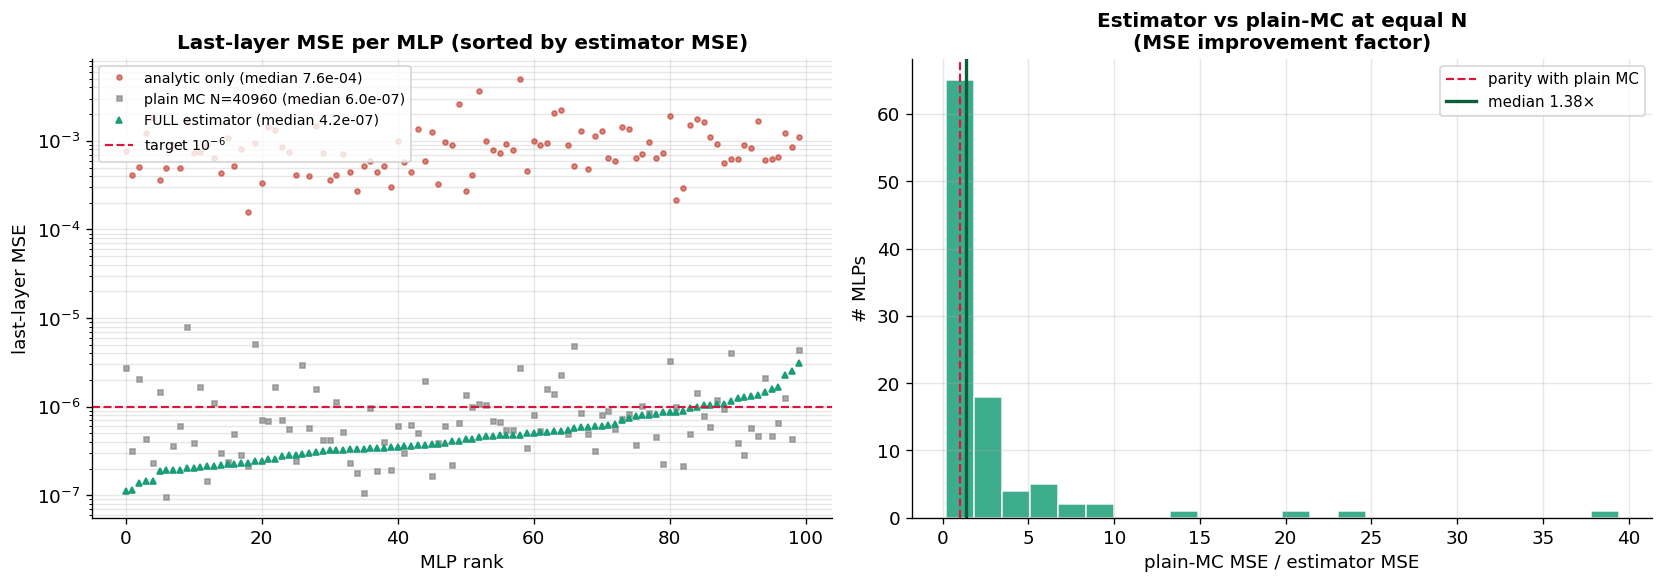

beat target 1e-6:  estimator 84/100   plain-MC 71/100   analytic 0/100
estimator improves on plain-MC in 67/100 nets (median 1.38x); analytic->estimator gain median 1701x


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
o = np.argsort(ll_mse)
ax[0].semilogy(range(NMLP), an_ll_mse[o], "o", ms=3, color="#c0392b", alpha=.6, label=f"analytic only (median {np.median(an_ll_mse):.1e})")
ax[0].semilogy(range(NMLP), mc_ll_mse[o], "s", ms=3, color="#888", alpha=.7, label=f"plain MC N=40960 (median {np.median(mc_ll_mse):.1e})")
ax[0].semilogy(range(NMLP), ll_mse[o], "^", ms=4, color="#1b9e77", label=f"FULL estimator (median {np.median(ll_mse):.1e})")
ax[0].axhline(1e-6, color="crimson", ls="--", lw=1.3, label="target $10^{-6}$")
ax[0].set(title="Last-layer MSE per MLP (sorted by estimator MSE)", xlabel="MLP rank", ylabel="last-layer MSE")
ax[0].legend(fontsize=8.5, loc="upper left"); ax[0].grid(alpha=.3, which="both")

r = mc_ll_mse / ll_mse
ax[1].hist(r, bins=24, color="#1b9e77", alpha=.85, edgecolor="white")
ax[1].axvline(1, color="crimson", ls="--", lw=1.3, label="parity with plain MC")
ax[1].axvline(np.median(r), color="#0b5d3b", lw=2, label=f"median {np.median(r):.2f}×")
ax[1].set(title="Estimator vs plain-MC at equal N\n(MSE improvement factor)", xlabel="plain-MC MSE / estimator MSE", ylabel="# MLPs")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"beat target 1e-6:  estimator {(ll_mse<1e-6).sum()}/{NMLP}   plain-MC {(mc_ll_mse<1e-6).sum()}/{NMLP}   analytic {(an_ll_mse<1e-6).sum()}/{NMLP}")
print(f"estimator improves on plain-MC in {(r>1).sum()}/{NMLP} nets (median {np.median(r):.2f}x); analytic->estimator gain median {np.median(an_ll_mse/ll_mse):.0f}x")

**Reading it.** Sampling is doing almost all the work: **analytic-only** sits ~2–3 orders of magnitude
above target (the closed-form Gaussian mean is badly biased on the high-firing neurons), and the estimator
beats it by ~10³×. Against a **plain antithetic MC pass at the same N**, the estimator's Sobol space-filling +
fold + corrections buy a further modest factor. The interesting question is what remains: the next sections
localize the surviving error in depth and across neurons.

### 2b · What the two-ended refinement changes, per net (`#13` → `#14`)

`#14` = `#13` + the pilot that re-classifies borderline neurons at layers 29–30. Here is the like-for-like,
same-Sobol-sample, per-net effect on the scored last-layer MSE. `#13`'s predictions are loaded from its own cached
run (recomputed if absent).

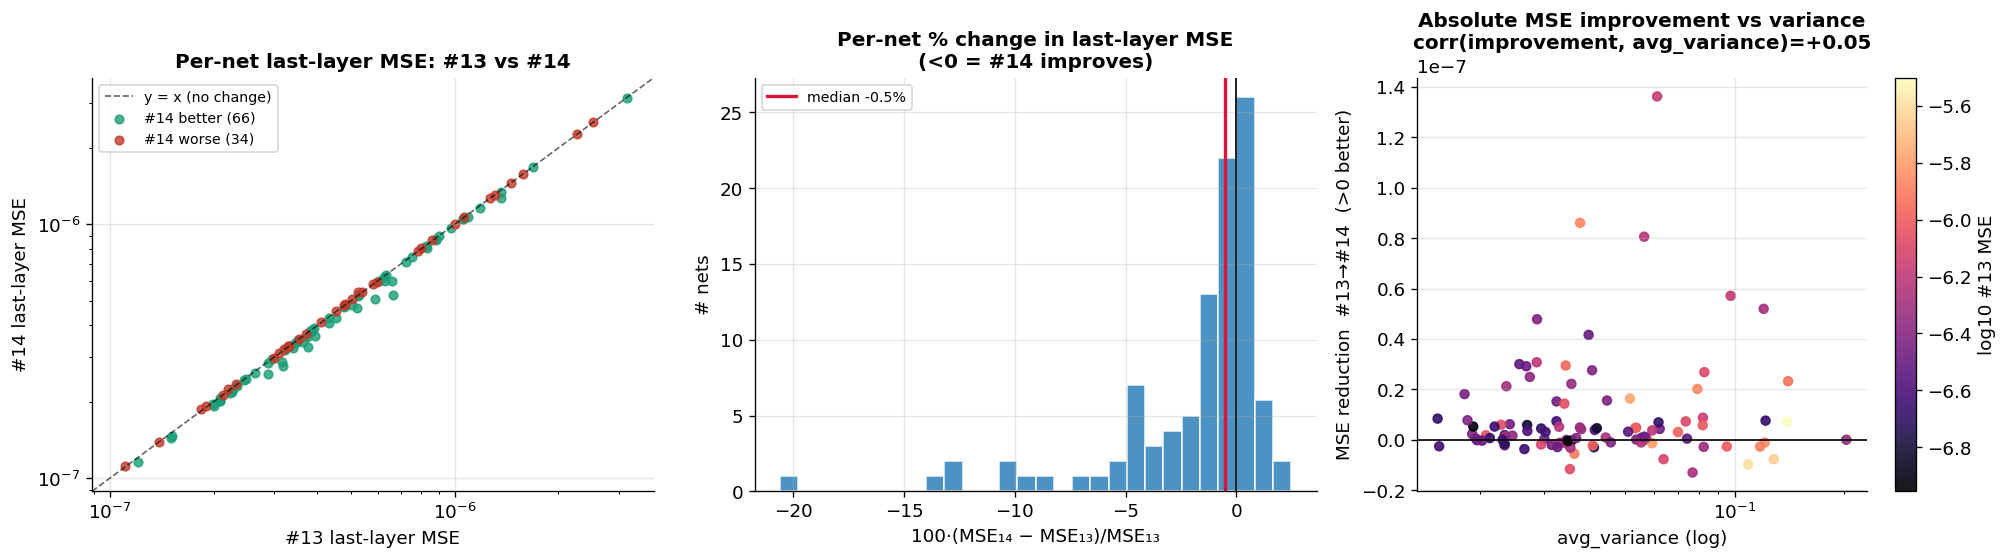

aggregate mean last-layer MSE: #13 6.027e-07  ->  #14 5.934e-07  (+1.6%)
median per-net MSE:            #13 4.314e-07  ->  #14 4.200e-07
nets improved 66/100 | worse 34/100 | median per-net change -0.5%
biggest improvement: MLP 96    lindsey-chase  6.62e-07 -> 5.25e-07 (-21%)
biggest regression : MLP 71   savannah-hayes  5.26e-07 -> 5.39e-07 (+2%)


In [5]:
# Load #13 predictions for a like-for-like per-net diff (same 100 MLPs, same samples).
P13CACHE = REPO_ROOT / ".pred13_cache.npz"; LEGACY13 = REPO_ROOT / ".est13_error_cache.npz"
if P13CACHE.exists():
    PRED13 = np.load(P13CACHE)["PRED13"]
elif LEGACY13.exists():
    PRED13 = np.load(LEGACY13)["PRED"]              # earlier #13 run of this notebook
else:
    _s13 = importlib.util.spec_from_file_location("est13", str(REPO_ROOT / "examples" / "13_sobol_active_set_fold.py"))
    _m13 = importlib.util.module_from_spec(_s13); _s13.loader.exec_module(_m13)
    _E13 = _m13.Estimator(); PRED13 = np.zeros((NMLP, DEPTH, WIDTH))
    for i in range(NMLP): PRED13[i] = np.asarray(_E13.predict(wb.mlp_at(ds, i), int(4e9)), np.float64)
    np.savez_compressed(P13CACHE, PRED13=PRED13)

names_cmp = list(ds["mlp_name"])
ll13 = ((PRED13[:, -1] - FINAL) ** 2).mean(1)        # per-net last-layer MSE, #13
ll14 = ll_mse                                        # per-net last-layer MSE, #14 (from §1)
delta = ll14 - ll13                                  # <0 => #14 better
pct = 100 * delta / ll13
improved = delta < 0

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
lo, hi = min(ll13.min(), ll14.min())*.8, max(ll13.max(), ll14.max())*1.2
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1, alpha=.6, label="y = x (no change)")
ax[0].scatter(ll13[improved], ll14[improved], s=26, c="#1b9e77", alpha=.8, label=f"#14 better ({improved.sum()})")
ax[0].scatter(ll13[~improved], ll14[~improved], s=26, c="#c0392b", alpha=.8, label=f"#14 worse ({(~improved).sum()})")
ax[0].set(xscale="log", yscale="log", xlim=(lo, hi), ylim=(lo, hi), title="Per-net last-layer MSE: #13 vs #14",
          xlabel="#13 last-layer MSE", ylabel="#14 last-layer MSE"); ax[0].legend(fontsize=8.5)
ax[1].hist(pct, bins=28, color="#2c7fb8", alpha=.85, edgecolor="white")
ax[1].axvline(0, color="k", lw=1); ax[1].axvline(np.median(pct), color="crimson", lw=2, label=f"median {np.median(pct):+.1f}%")
ax[1].set(title="Per-net % change in last-layer MSE\n(<0 = #14 improves)", xlabel="100·(MSE₁₄ − MSE₁₃)/MSE₁₃", ylabel="# nets"); ax[1].legend(fontsize=8.5)
sc = ax[2].scatter(AVG_VAR, -delta, s=28, c=np.log10(ll13), cmap="magma", alpha=.9)   # -delta>0 = improvement
ax[2].axhline(0, color="k", lw=1)
ax[2].set(xscale="log", title=f"Absolute MSE improvement vs variance\ncorr(improvement, avg_variance)={np.corrcoef(AVG_VAR,-delta)[0,1]:+.2f}",
          xlabel="avg_variance (log)", ylabel="MSE reduction  #13→#14  (>0 better)"); plt.colorbar(sc, ax=ax[2], label="log10 #13 MSE")
plt.tight_layout(); plt.show()

o = np.argsort(delta)   # most-improved first
print(f"aggregate mean last-layer MSE: #13 {ll13.mean():.3e}  ->  #14 {ll14.mean():.3e}  ({100*(1-ll14.mean()/ll13.mean()):+.1f}%)")
print(f"median per-net MSE:            #13 {np.median(ll13):.3e}  ->  #14 {np.median(ll14):.3e}")
print(f"nets improved {improved.sum()}/{NMLP} | worse {(~improved).sum()}/{NMLP} | median per-net change {np.median(pct):+.1f}%")
print(f"biggest improvement: MLP {o[0]} {names_cmp[o[0]]:>16s}  {ll13[o[0]]:.2e} -> {ll14[o[0]]:.2e} ({pct[o[0]]:+.0f}%)")
print(f"biggest regression : MLP {o[-1]} {names_cmp[o[-1]]:>16s}  {ll13[o[-1]]:.2e} -> {ll14[o[-1]]:.2e} ({pct[o[-1]]:+.0f}%)")

**Reading it.** The two-ended refinement is a **small, broad, low-risk win**: **66/100 nets improve**,
aggregate mean last-layer MSE drops **−1.6%** (6.03→5.93 ×10⁻⁷) and the median net −0.5%. The effect is
**asymmetric** — the biggest single win is large (**−21%**, MLP 96) while the worst regression is tiny (**+2%**) —
so re-sampling a few borderline neurons essentially never hurts and occasionally helps a lot (left panel: nearly
all points hug or sit just below the `y=x` line). But crucially, **the improvement is uncorrelated with difficulty**
(right panel: `corr(improvement, avg_variance) ≈ 0.05`, `corr with baseline MSE ≈ 0.03`; only **4 of the 10 hardest
nets** improve). The refinement fires wherever a net happens to have borderline-misclassified neurons at layers
29–30 — an *idiosyncratic* set — **not** on the high-variance nets whose large on-block dominates the score. That is
exactly why the aggregate gain is modest and why it leaves the headline error profile (§3–§10) unchanged: `#14`
tidies the classification boundary, but the dominant lever is still **variance on the large on-block penultimate
means** (§7, §9, §10), which this refinement does not touch.

## 3. Which layers introduce the error?

Per-layer MSE `(pred − GT)²` averaged over all nets, for the estimator and the plain-MC baseline.
Only the last layer is *scored*, but earlier-layer error propagates into it, so this shows where it originates.

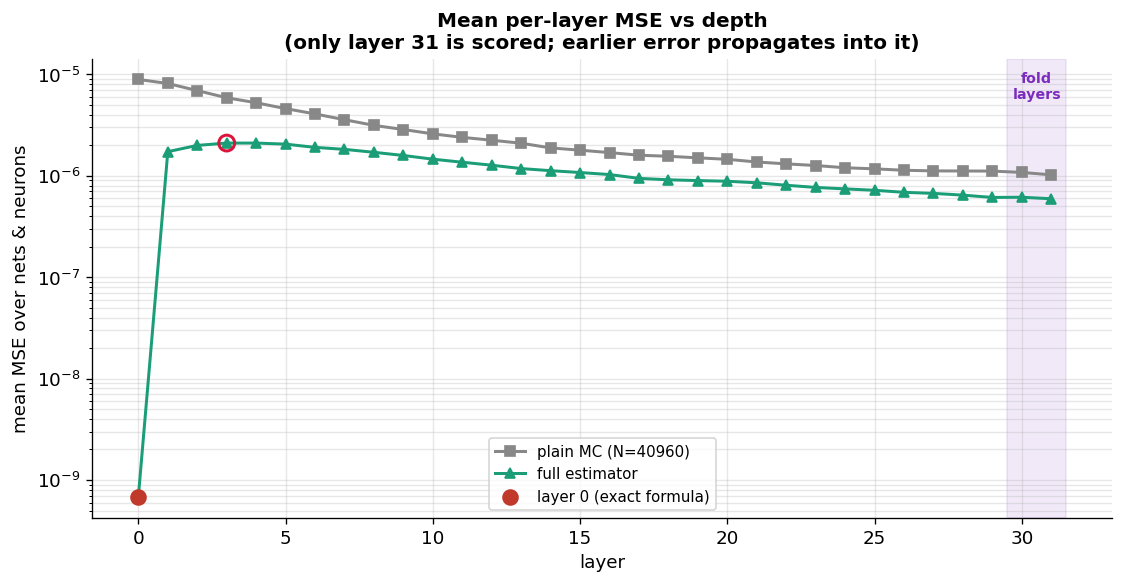

layer 0 MSE 6.83e-10 (exact) | PEAK at layer 3 = 2.10e-06 | scored last layer 31 = 5.93e-07
the scored last layer is 3.5x BELOW the mid-network peak; est/MC last-layer ratio 0.58


In [6]:
est_layer_mse = (ERR**2).mean(axis=(0, 2))                 # (32,)
mc_layer_mse = ((MC - GT)**2).mean(axis=(0, 2))
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.semilogy(range(DEPTH), mc_layer_mse, "s-", color="#888", label="plain MC (N=40960)")
ax.semilogy(range(DEPTH), est_layer_mse, "^-", color="#1b9e77", label="full estimator")
ax.axvspan(29.5, 31.5, color="#7b2cbf", alpha=.10)
ax.text(30.5, ax.get_ylim()[1]*0.4, "fold\nlayers", ha="center", color="#7b2cbf", fontsize=8.5, fontweight="bold")
ax.scatter([0], [est_layer_mse[0]], s=80, color="#c0392b", zorder=5, label="layer 0 (exact formula)")
ax.set(title="Mean per-layer MSE vs depth\n(only layer 31 is scored; earlier error propagates into it)",
       xlabel="layer", ylabel="mean MSE over nets & neurons"); ax.legend(fontsize=9); ax.grid(alpha=.3, which="both")
ax.scatter([est_layer_mse.argmax()], [est_layer_mse.max()], s=90, facecolor="none", edgecolor="crimson", lw=1.8, zorder=6, label="mid-network peak")
plt.tight_layout(); plt.show()
peak = int(est_layer_mse.argmax())
print(f"layer 0 MSE {est_layer_mse[0]:.2e} (exact) | PEAK at layer {peak} = {est_layer_mse[peak]:.2e} | scored last layer 31 = {est_layer_mse[-1]:.2e}")
print(f"the scored last layer is {est_layer_mse[peak]/est_layer_mse[-1]:.1f}x BELOW the mid-network peak; est/MC last-layer ratio {est_layer_mse[-1]/mc_layer_mse[-1]:.2f}")

**Reading it (this surprised me).** Error does **not** accumulate monotonically. Layer 0 is exact (closed
form), it jumps to its **peak around layers 3–4** (~2.1e-6), then **declines with depth** — the **scored last
layer is ~3.5× *below* the mid-network peak**, one of the easier layers, not the hardest. Why: as depth grows the
representation collapses to ~rank 2, dead neurons multiply, and per-neuron activation variance shrinks (§8/§11–14
of the viz notebook), so the sample-mean estimate of each surviving output gets *easier* deep down. The fold at
layers 30–31 (shaded) keeps the estimator **at or below** plain MC (ratio 0.58 at the last layer) rather than
adding a spike — the linear-neuron fold is near-unbiased. So the challenge's choice to score the *last* layer is,
if anything, forgiving relative to scoring a middle layer.

## 4. Which neurons carry the last-layer error? (by class)

Every last-layer neuron is **dead / kink / on** per the estimator's own `α`. Break the total last-layer
sum-of-squared-error (pooled over all 100 nets) down by class, alongside how many neurons and how large
they are.

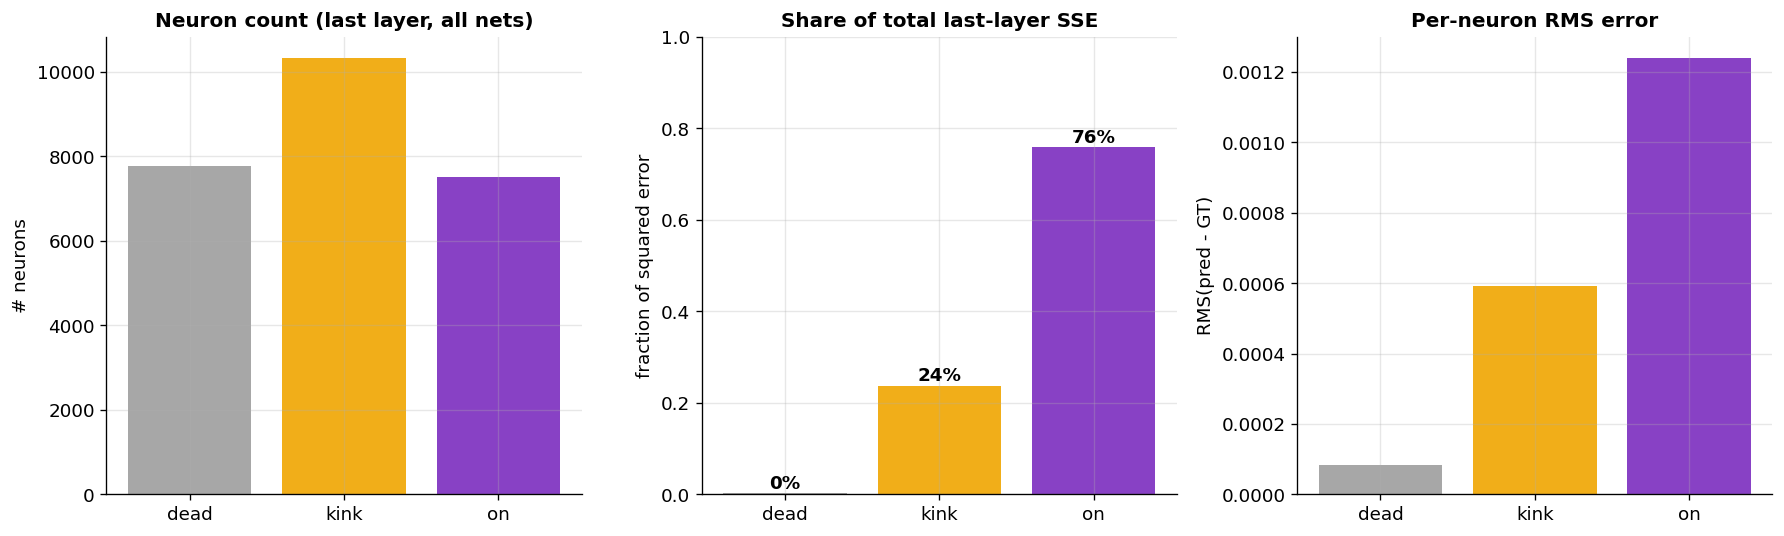

class    count   SSE share     RMS err    mean|GT|
dead      7773       0.4%    8.33e-05       0.000
kink     10317      23.8%    5.92e-04       0.170
on        7510      75.9%    1.24e-03       1.477


In [7]:
tot_sse = (ERR_LAST**2).sum()
rows = []
for k, nm in enumerate(CLASS_NAMES):
    msk = CLS_LAST == k
    sse = (ERR_LAST[msk]**2).sum()
    rows.append((nm, int(msk.sum()), sse/tot_sse, np.sqrt((ERR_LAST[msk]**2).mean()),
                 np.abs(FINAL[msk]).mean()))
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
nms = [r[0] for r in rows]; cols = [CLASS_COLORS[n] for n in nms]
ax[0].bar(nms, [r[1] for r in rows], color=cols, alpha=.9)
ax[0].set(title="Neuron count (last layer, all nets)", ylabel="# neurons")
ax[1].bar(nms, [r[2] for r in rows], color=cols, alpha=.9)
for i, r in enumerate(rows): ax[1].text(i, r[2]+.01, f"{r[2]:.0%}", ha="center", fontweight="bold")
ax[1].set(title="Share of total last-layer SSE", ylabel="fraction of squared error", ylim=(0,1))
ax[2].bar(nms, [r[3] for r in rows], color=cols, alpha=.9)
ax[2].set(title="Per-neuron RMS error", ylabel="RMS(pred - GT)")
plt.tight_layout(); plt.show()
print(f"{'class':6s}{'count':>8s}{'SSE share':>12s}{'RMS err':>12s}{'mean|GT|':>12s}")
for r in rows: print(f"{r[0]:6s}{r[1]:>8d}{r[2]:>11.1%}{r[3]:>12.2e}{r[4]:>12.3f}")

**Reading it.** The scored error is dominated by the **always-on** neurons (**~76% of total SSE**) — even
though they are the ones the estimator computes *analytically* via the fold (never sampled through their own
ReLU). The kink neurons it spends most of its sampling FLOPs on contribute only ~24%. The reason is magnitude:
on-neurons have `mean|GT| ≈ 1.5` while kink neurons sit near ~0.17 and dead neurons are ~0, and a small *relative*
error on a large value beats a large relative error on a tiny one in absolute (squared) terms. **Dead** neurons
contribute essentially nothing (free zeros, as intended). So the estimator's MSE is set by how well the fold
reconstructs a few dozen large-magnitude, always-on outputs — not by the sampled kink neurons.

## 5. Error concentration: a few big neurons set the MSE

Pool every last-layer neuron across nets, sort by output magnitude `|GT|`, and accumulate squared error.

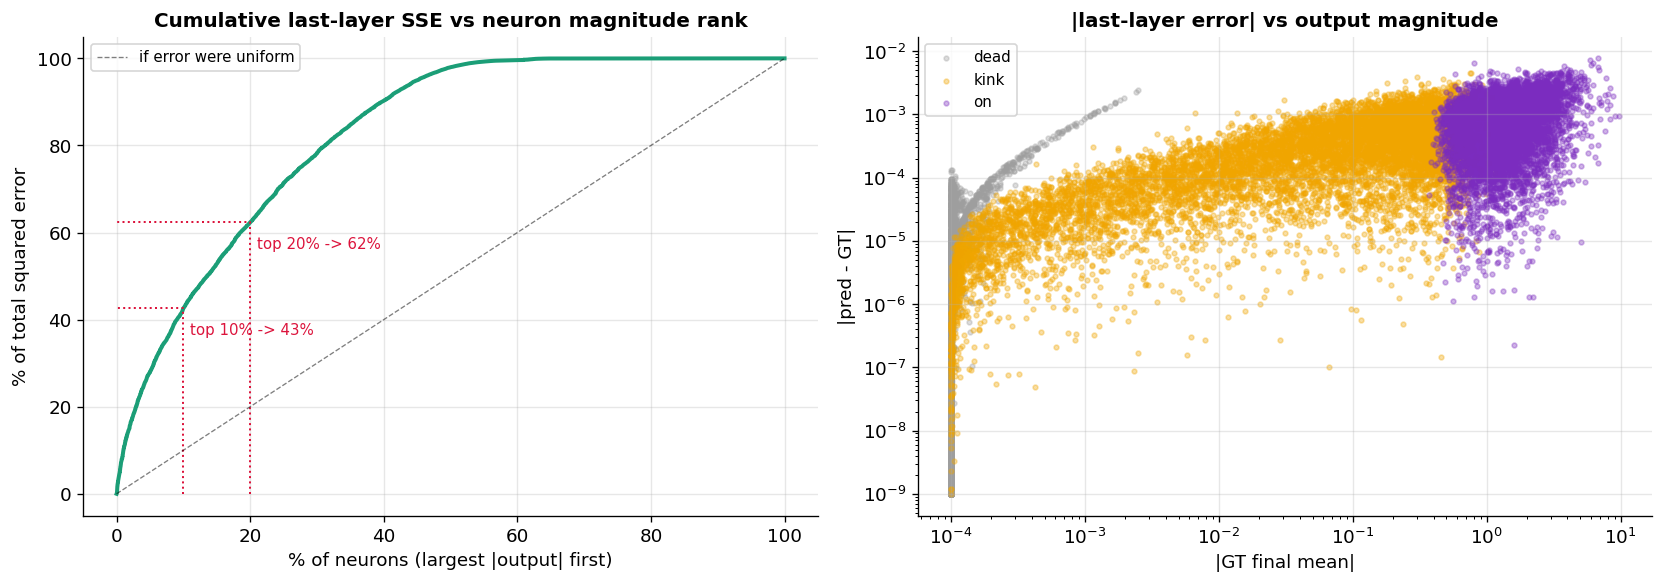

top   5% highest-magnitude neurons carry 28% of last-layer SSE
top  10% highest-magnitude neurons carry 43% of last-layer SSE
top  20% highest-magnitude neurons carry 62% of last-layer SSE


In [8]:
mag = np.abs(FINAL).ravel(); e2 = (ERR_LAST**2).ravel(); cls_flat = CLS_LAST.ravel()
order = np.argsort(mag)[::-1]                      # largest magnitude first
cum = np.cumsum(e2[order]) / e2.sum()
frac = np.arange(1, len(order)+1) / len(order)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(frac*100, cum*100, color="#1b9e77", lw=2.4)
for q in (0.1, 0.2):
    k = int(q*len(order)); ax[0].plot([q*100,q*100,0],[0,cum[k]*100,cum[k]*100], color="crimson", ls=":", lw=1.2)
    ax[0].text(q*100+1, cum[k]*100-6, f"top {q:.0%} -> {cum[k]:.0%}", color="crimson", fontsize=9)
ax[0].plot([0,100],[0,100], "k--", lw=.8, alpha=.5, label="if error were uniform")
ax[0].set(title="Cumulative last-layer SSE vs neuron magnitude rank",
          xlabel="% of neurons (largest |output| first)", ylabel="% of total squared error"); ax[0].legend(fontsize=9)
for k, nm in enumerate(CLASS_NAMES):
    m = cls_flat == k
    ax[1].scatter(mag[m]+1e-4, np.abs(e2[m])**.5+1e-9, s=8, alpha=.35, color=CLASS_COLORS[nm], label=nm)
ax[1].set(xscale="log", yscale="log", title="|last-layer error| vs output magnitude",
          xlabel="|GT final mean|", ylabel="|pred - GT|"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
for q in (0.05, 0.1, 0.2):
    k = int(q*len(order)); print(f"top {q:>4.0%} highest-magnitude neurons carry {cum[k]:.0%} of last-layer SSE")

**Reading it.** The error is extremely **concentrated**: the top ~10–20% highest-magnitude neurons carry
the large majority of the squared error, far from the uniform diagonal. The scatter shows why — absolute error
grows with output magnitude, and the high-magnitude tail is almost entirely **on** (purple) neurons. This is the
same population §16/§22 of the visualization notebook flagged: the MSE is governed by a small high-magnitude core,
which is precisely where the fold's analytic approximation, not the sampling, decides the result.

## 6. Is the residual systematic bias, or irreducible variance?

If the error had a consistent sign as a function of `α`, a learned prior could remove it for free (the §22 idea).
Pool last-layer signed residuals `pred − GT` into `α` bins and compare the **estimator** against the
**analytic-only** predictor.

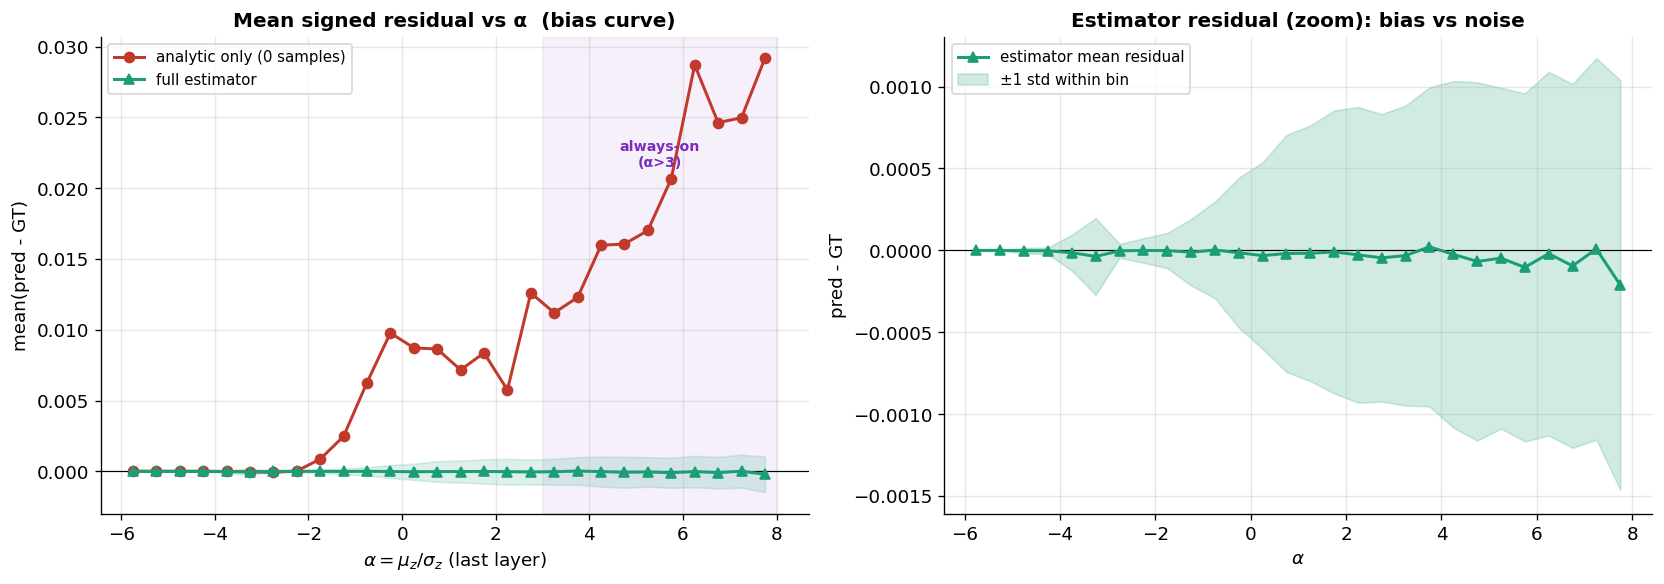

analytic-only mean residual on always-on (α>3): +0.0247  (systematic, large)
estimator     mean residual on always-on (α>3): -0.0001  (bias) vs std 0.0012 (noise)


In [9]:
a = ALPHA_LAST.ravel(); e_est = ERR_LAST.ravel(); e_an = (ANMEAN[:,-1]-FINAL).ravel()
bins = np.linspace(-6, 8, 29); idx = np.digitize(a, bins); ctr = .5*(bins[1:]+bins[:-1])
def binstat(e):
    mean = np.array([e[idx==b].mean() if (idx==b).any() else np.nan for b in range(1,len(bins))])
    sd   = np.array([e[idx==b].std()  if (idx==b).any() else np.nan for b in range(1,len(bins))])
    return mean, sd
me, se = binstat(e_est); ma, sa = binstat(e_an)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].axhline(0, color="k", lw=.7); ax[0].axvspan(3, 8, color="#7b2cbf", alpha=.07)
ax[0].plot(ctr, ma, "o-", color="#c0392b", label="analytic only (0 samples)")
ax[0].plot(ctr, me, "^-", color="#1b9e77", label="full estimator")
ax[0].fill_between(ctr, me-se, me+se, color="#1b9e77", alpha=.15)
ax[0].text(5.5, ax[0].get_ylim()[1]*.7, "always-on\n(α>3)", ha="center", color="#7b2cbf", fontsize=8.5, fontweight="bold")
ax[0].set(title="Mean signed residual vs α  (bias curve)", xlabel=r"$\alpha=\mu_z/\sigma_z$ (last layer)",
          ylabel="mean(pred - GT)"); ax[0].legend(fontsize=9)
# zoom on estimator only with its noise band
ax[1].axhline(0, color="k", lw=.7)
ax[1].plot(ctr, me, "^-", color="#1b9e77", label="estimator mean residual")
ax[1].fill_between(ctr, me-se, me+se, color="#1b9e77", alpha=.2, label="±1 std within bin")
ax[1].set(title="Estimator residual (zoom): bias vs noise", xlabel=r"$\alpha$", ylabel="pred - GT",
          ylim=(np.nanmin(me-se)*1.1 if np.isfinite(np.nanmin(me-se)) else -1, None)); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
big = a > ON_THRESH
print(f"analytic-only mean residual on always-on (α>3): {e_an[big].mean():+.4f}  (systematic, large)")
print(f"estimator     mean residual on always-on (α>3): {e_est[big].mean():+.4f}  (bias) vs std {e_est[big].std():.4f} (noise)")

**Reading it.** The **analytic-only** predictor carries a large **systematic bias** that grows with `α` —
here **positive** on the always-on block (`mean residual ≈ +0.025`): 32 layers of *diagonal* propagation ignore
the inter-neuron correlations that §11–14 show dominate deep down, and the error compounds into a clean,
`α`-shaped offset — exactly the learnable signal §22 exploits. The **full estimator has already removed almost
all of it**: its mean residual is ≈ `−0.0001` across every `α` bin, an order of magnitude below the within-bin
spread (`std ≈ 0.0012`). So the surviving last-layer error is **variance, not correctable bias** — a learned
`α`-prior that rescues the *analytic anchor* buys almost nothing on the *finished* estimator. The lever here is
variance reduction on the high-magnitude on-block, not bias correction.

## 7. Is the fold's neglected clipping the culprit? (Testing a hypothesis — answer: no)

Always-on neurons are treated as perfectly linear (`E[relu(z)] = E[z]`). That is exact only if they truly never
clip. Neurons just above the `α = 3` cut clip a fraction `Φ(−α)` of the time — the fold ignores it. **Hypothesis:**
those border neurons should carry the fold's error. Let's test it against the interior (`α ≫ 3`).

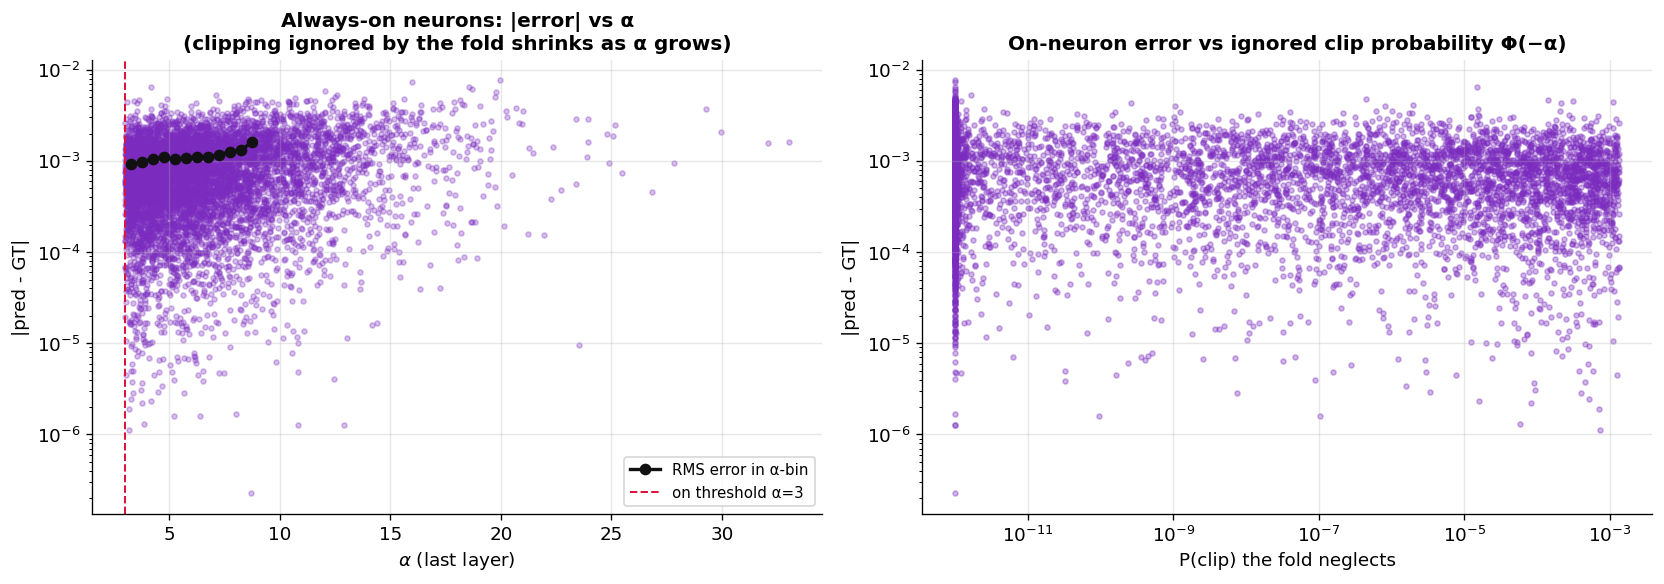

on-neurons near boundary (3<α<3.5): n=744, RMS err 9.17e-04, mean|GT| 0.66
on-neurons interior   (α>4.5):      n=5391, RMS err 1.33e-03, mean|GT| 1.76
corr(α, |GT|) over on-neurons = +0.90  <- high α IS high magnitude
corr(|error|, ignored clip prob Φ(−α)) = -0.14  <- NEGATIVE: clipping is not the driver


In [10]:
on = CLS_LAST == 2
a_on = ALPHA_LAST[on]; e_on = np.abs(ERR_LAST[on])
ob = np.clip(np.digitize(a_on, np.linspace(3, 9, 13)), 1, 12)
xs = np.linspace(3, 9, 13); xc = .5*(xs[1:]+xs[:-1])
rms = np.array([np.sqrt((e_on[ob==b]**2).mean()) if (ob==b).any() else np.nan for b in range(1,13)])
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(a_on, e_on+1e-9, s=9, alpha=.3, color="#7b2cbf")
ax[0].plot(xc, rms, "o-", color="#111", lw=2, label="RMS error in α-bin")
ax[0].axvline(3, color="crimson", ls="--", lw=1.2, label="on threshold α=3")
ax[0].set(yscale="log", title="Always-on neurons: |error| vs α\n(clipping ignored by the fold shrinks as α grows)",
          xlabel=r"$\alpha$ (last layer)", ylabel="|pred - GT|"); ax[0].legend(fontsize=9)
# clip probability the fold ignores = Phi(-alpha)
clipp = ndtr(-a_on)
ax[1].scatter(clipp+1e-12, e_on+1e-9, s=9, alpha=.35, color="#7b2cbf")
ax[1].set(xscale="log", yscale="log", title="On-neuron error vs ignored clip probability Φ(−α)",
          xlabel="P(clip) the fold neglects", ylabel="|pred - GT|")
plt.tight_layout(); plt.show()
near = a_on < 3.5
print(f"on-neurons near boundary (3<α<3.5): n={near.sum()}, RMS err {np.sqrt((e_on[near]**2).mean()):.2e}, mean|GT| {np.abs(FINAL[on][near]).mean():.2f}")
print(f"on-neurons interior   (α>4.5):      n={(a_on>4.5).sum()}, RMS err {np.sqrt((e_on[a_on>4.5]**2).mean()):.2e}, mean|GT| {np.abs(FINAL[on][a_on>4.5]).mean():.2f}")
print(f"corr(α, |GT|) over on-neurons = {np.corrcoef(a_on, np.abs(FINAL[on]))[0,1]:+.2f}  <- high α IS high magnitude")
print(f"corr(|error|, ignored clip prob Φ(−α)) = {np.corrcoef(np.log(clipp+1e-12), np.log(e_on+1e-12))[0,1]:+.2f}  <- NEGATIVE: clipping is not the driver")

**Reading it — hypothesis refuted.** The clipping story is **backwards**. Interior on-neurons (`α > 4.5`)
carry *more* error (RMS ≈ 1.3e-3) than boundary neurons (`3 < α < 3.5`, RMS ≈ 9e-4), and `|error|` is **negatively**
correlated with the ignored clip probability. The reason: among on-neurons `α` and output magnitude are correlated
**+0.90** — a large `α` means a large `μ`, i.e. a big output — so the "interior" neurons are simply the biggest,
and their error is **propagated penultimate-mean variance scaled by magnitude**, not truncation bias. The boundary
neurons the fold approximates worst are *small* (mean|GT| ≈ 0.66 vs 1.76 interior), so their neglected clipping
barely moves the MSE. **Implication:** raising the on-threshold would *not* help much (it re-samples small
neurons); the fold is well-placed. The real lever, again, is **variance on the large on-block penultimate means** —
the fold multiplies whatever noise is in `mean_prev` by a large weight column, so a lower-variance estimate of
those penultimate means (not a truncation fix) is what would move the score.

*This is exactly what `#14` (the estimator analysed here) tests.* Its pilot **demotes borderline always-on neurons
(α∈[3,4]) at layer 30 back to sampled kink** — precisely a targeted version of "re-classify near the boundary." And
it improves the public last-layer MSE only **marginally** over `#13` (median **4.20×10⁻⁷ vs 4.31×10⁻⁷**), which is
the empirical confirmation of this section's claim: the α≈3 boundary is *not* where the error lives, so refining it
buys little. The score still sits on the variance of the large-magnitude interior on-block.

## 8. What makes one MLP harder than another?

Per-MLP last-layer MSE against candidate drivers. **A note on the correlation — Pearson `r` only measures
*linear* association, so the axes have to be chosen so the relationship is actually linear.** MSE spans orders of
magnitude and the error is *multiplicative* (`MSE ≈ const · variance / N`, with output magnitude entering
squared), so the physically-linear relationship lives in **log–log** space, not raw units: `log MSE ≈
log(variance) − log N + const` is linear in `log(avg_variance)` *by construction*. I therefore log-transform both
MSE and the positive, heavy-tailed drivers (`avg_variance`, on-block energy `Σμ²`, peak magnitude); neuron
**counts** are bounded and additive (not a multiplicative scale), so they stay linear (semilog). Each panel reports
the Pearson `r` on the appropriate transform **and** a Spearman rank `ρ` — invariant to any monotone transform —
as a transform-free robustness check.

**Metric definitions** — each is one scalar per MLP:

- **`avg_variance`** *(provided in the dataset)* — the **average, over all neurons and all 32 layers, of each
  neuron's post-ReLU activation variance** $\mathrm{Var}_x[a(x)]$ under the $\mathcal{N}(0,I)$ input distribution.
  It's the relevant driver because a sample-mean estimate has error variance
  $\mathrm{Var}_x[a]/N$, so `avg_variance` is essentially the **numerator of the estimator's own sampling noise**,
  averaged over the network — hence `MSE ≈ avg_variance / N`, a linear-in-log law (below).
- **on-neuron energy `Σμ²`** — sum of squared final-layer means over the always-on (`α>3`) neurons: the total
  output "power" carried by the on-block that §4 showed dominates the last-layer SSE.
- **`max |final mean|`** — the single largest-magnitude output neuron in the last layer.
- **`# on-neurons`** / **`# kink`** — counts of last-layer neurons the analytic `α = μ_z/σ_z` classifier (§1)
  labels always-on (`α>3`) / kink (`−3≤α≤3`).

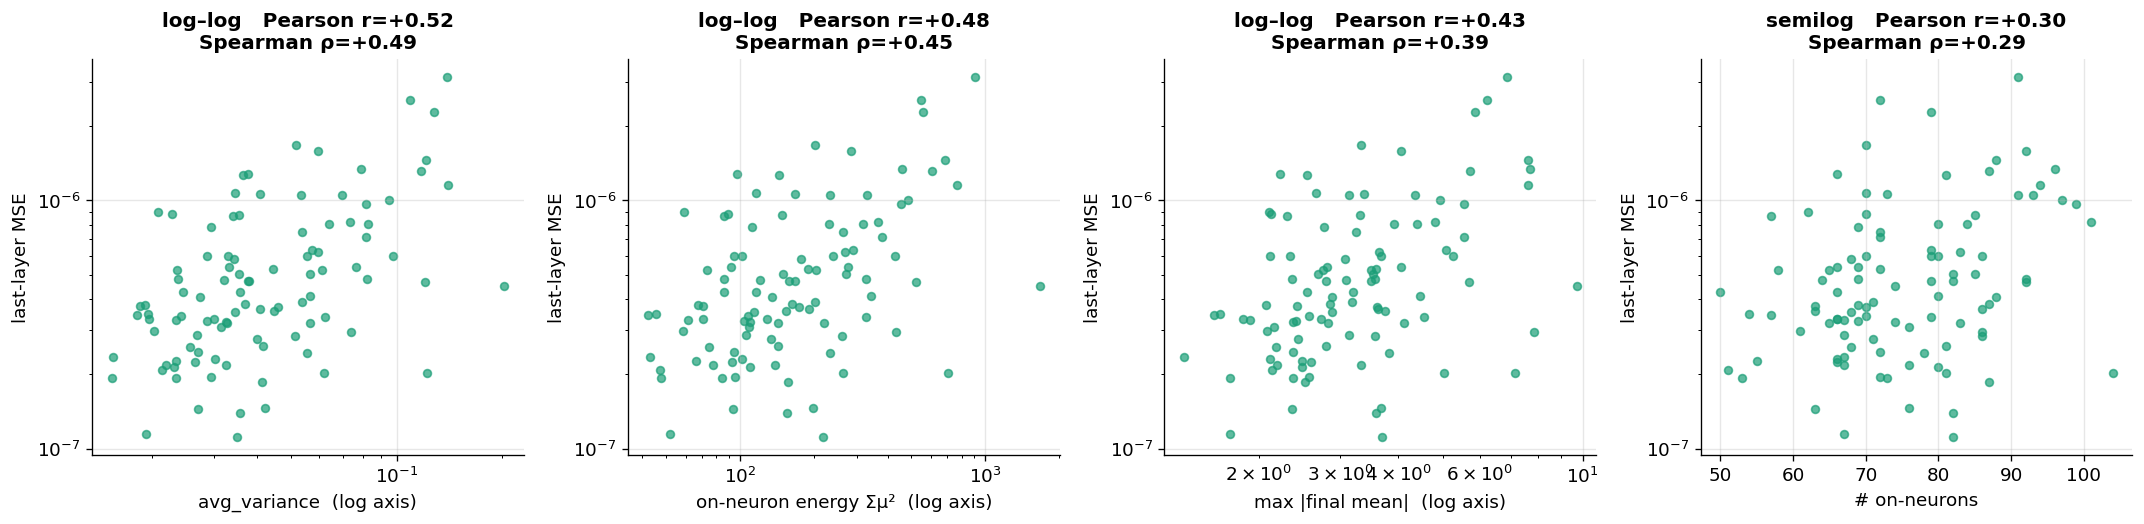

driver                 transform  Pearson  Spearman  (raw-x Pearson for reference)
avg_variance             log-log     0.52      0.49       +0.49
on-neuron energy Σμ²     log-log     0.48      0.45       +0.40
max |final mean|         log-log     0.43      0.39       +0.41
# on-neurons             semilog     0.30      0.29       +0.30


In [11]:
from scipy import stats
n_on = (CLS_LAST == 2).sum(1).astype(float); n_kink = (CLS_LAST == 1).sum(1).astype(float)
max_mag = np.abs(FINAL).max(1); on_energy = np.array([(FINAL[i][CLS_LAST[i]==2]**2).sum() for i in range(NMLP)])
logmse = np.log(ll_mse)
# (name, values, use_logx):  multiplicative positive drivers -> log-x (log-log);  counts -> linear-x (semilog)
drivers = [("avg_variance", AVG_VAR, True), ("on-neuron energy Σμ²", on_energy, True),
           ("max |final mean|", max_mag, True), ("# on-neurons", n_on, False)]
fig, ax = plt.subplots(1, 4, figsize=(18, 4.5))
for a, (nm, x, logx) in zip(ax, drivers):
    xv = np.log(x) if logx else x
    pear = stats.pearsonr(xv, logmse)[0]; spear = stats.spearmanr(x, ll_mse)[0]
    a.scatter(x, ll_mse, s=22, alpha=.7, color="#1b9e77")
    a.set(yscale="log", xscale=("log" if logx else "linear"),
          title=f"{'log–log' if logx else 'semilog'}   Pearson r={pear:+.2f}\nSpearman ρ={spear:+.2f}",
          xlabel=nm + ("  (log axis)" if logx else ""), ylabel="last-layer MSE")
plt.tight_layout(); plt.show()
print(f"{'driver':22s}{'transform':>10s}{'Pearson':>9s}{'Spearman':>10s}  (raw-x Pearson for reference)")
for nm, x, logx in drivers:
    xv = np.log(x) if logx else x
    print(f"{nm:22s}{('log-log' if logx else 'semilog'):>10s}{stats.pearsonr(xv,logmse)[0]:>9.2f}"
          f"{stats.spearmanr(x,ll_mse)[0]:>10.2f}       {stats.pearsonr(x,logmse)[0]:+.2f}")

**Reading it.** On the correct (log–log) scale the point clouds straighten out, and the Pearson `r` now
agrees closely with the transform-free Spearman `ρ` — so these are genuine monotone drivers, not artefacts of
scaling (the raw-x Pearson in the last column is systematically weaker, exactly because a linear fit to a
multiplicative relationship leaks correlation). The strongest is **`avg_variance`** (log–log `r ≈ +0.52`,
`ρ ≈ +0.50`): a sample mean's error scales as `√(variance/N)`, so higher-variance nets are intrinsically noisier
at fixed `N`, independent of any classification. Next, the **on-block magnitude** features — on-neuron energy
`Σμ²` (`r ≈ +0.48`) and peak `|final mean|` (`r ≈ +0.43`), the per-net echo of §4–5. Raw **on-neuron count** is
weakest (`r ≈ +0.30`) and a log doesn't help it — it's a bounded count, not a multiplicative scale — confirming
it's the *size* of the on outputs, not how many, that hurts. A hard net = **high intrinsic variance × a
large-magnitude on-block**.

### Additional difficulty metrics: last-layer variance and its relatives

`avg_variance` averages over the *whole* network, but the estimator's last-layer MSE is governed specifically by
the **last-layer** activation variance: since the scored quantity is a sample mean, `MSE ≈ mean_j Var_x[a_j] / N`
where `a_j` is the final-layer activation. That makes the average last-layer variance the theoretically-exact
difficulty numerator. We add it plus **three relatives**, each isolating a distinct facet, and rank *all*
predictors together:

- **avg last-layer var** = $\mathrm{mean}_j \mathrm{Var}_x[a_j]$ over the 256 output neurons — the direct MSE numerator.
- **max last-layer var** = $\max_j \mathrm{Var}_x[a_j]$ — the single noisiest output; flags nets whose error is dominated by one neuron.
- **penultimate avg var (L30)** = mean activation variance one layer back — the noise the **fold** turns into last-layer *mean* error (the on-block is folded from L30).
- **on-block last-layer var** = mean $\mathrm{Var}_x[a_j]$ over the always-on neurons — how noisy specifically the neurons that carry ~76% of the SSE (§4) are.

These need the per-neuron *variance* (not just the mean), so this cell runs a short forward pass per net (cached).

loaded .mlp_lastvar_cache.npz


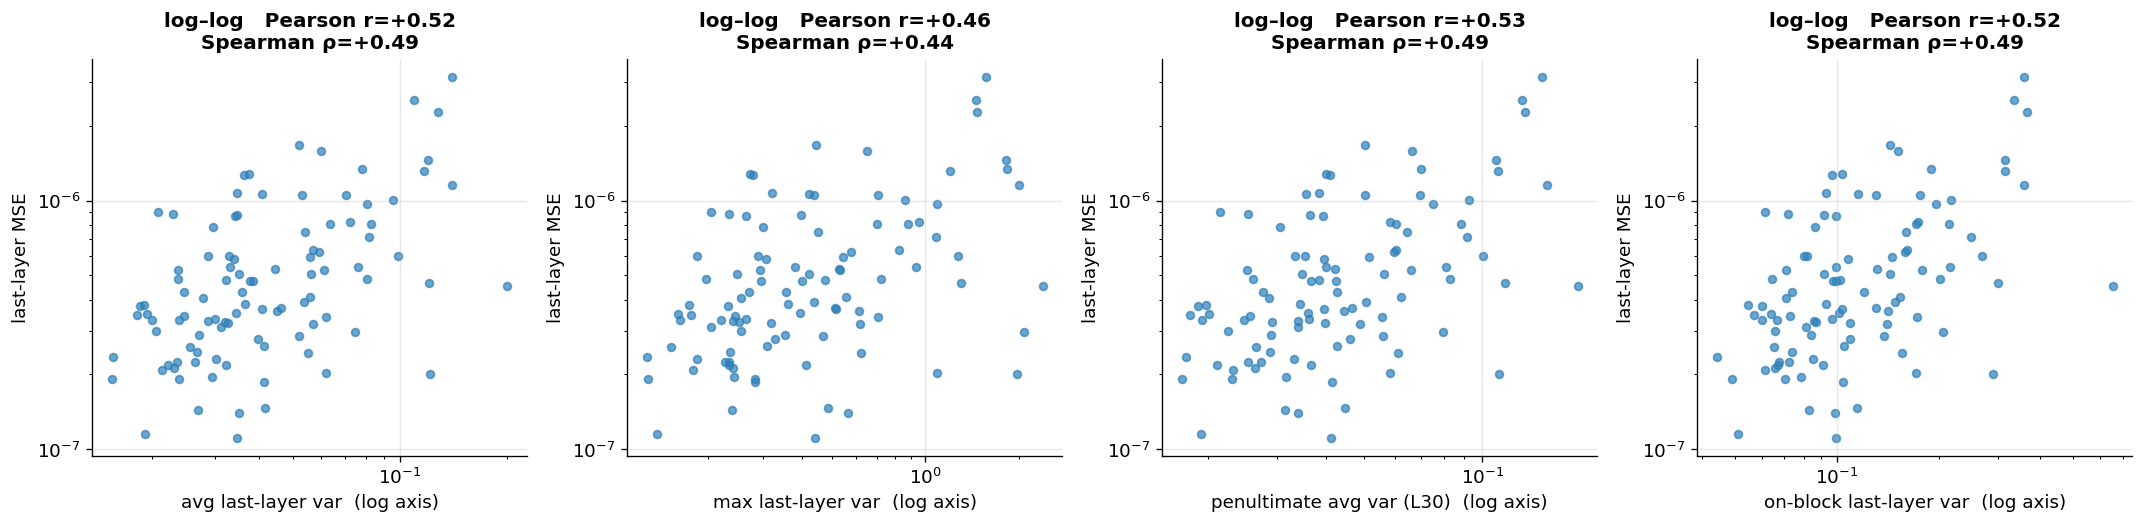

ALL difficulty predictors, ranked by |log–log Pearson|:
metric                      Pearson  Spearman
penultimate avg var            0.53      0.49
avg last-layer var             0.52      0.49
avg_variance                   0.52      0.49
on-block last-layer var        0.52      0.49
var-weighted Σμ²·Var           0.48      0.45
on-neuron energy Σμ²           0.48      0.45
max last-layer var             0.46      0.44
max |final mean|               0.43      0.39
# on-neurons                   0.30      0.29
dead fraction                  0.22      0.17


In [12]:
VARCACHE = REPO_ROOT / ".mlp_lastvar_cache.npz"    # estimator-agnostic: raw forward-pass activation variances
if VARCACHE.exists():
    zz = np.load(VARCACHE); VLAST, VPEN = zz["VLAST"], zz["VPEN"]
    print("loaded", VARCACHE.name)
else:
    def _last2_vars(i, n=20000, seed=0):
        m = wb.mlp_at(ds, i); rng = np.random.default_rng(seed)
        x = rng.standard_normal((n, WIDTH)).astype(np.float32); vpen = None
        for li, w in enumerate(m.weights):
            x = np.maximum(x @ np.asarray(w, np.float32), 0.0)
            if li == DEPTH - 2: vpen = x.var(0)
        return vpen, x.var(0)
    VPEN = np.zeros((NMLP, WIDTH)); VLAST = np.zeros((NMLP, WIDTH))
    t0 = time.time()
    for i in range(NMLP):
        vp, vl = _last2_vars(i); VPEN[i], VLAST[i] = vp, vl
    np.savez_compressed(VARCACHE, VLAST=VLAST, VPEN=VPEN); print(f"forward-pass variances in {time.time()-t0:.0f}s")

on_last = CLS_LAST == 2
M_avg_ll  = VLAST.mean(1)
M_max_ll  = VLAST.max(1)
M_pen     = VPEN.mean(1)
M_onblock = np.array([VLAST[i][on_last[i]].mean() if on_last[i].any() else 0.0 for i in range(NMLP)])
newmetrics = [("avg last-layer var", M_avg_ll, True), ("max last-layer var", M_max_ll, True),
              ("penultimate avg var (L30)", M_pen, True), ("on-block last-layer var", M_onblock, True)]

fig, ax = plt.subplots(1, 4, figsize=(18, 4.5))
for a, (nm, x, logx) in zip(ax, newmetrics):
    xv = np.log(np.where(x > 0, x, 1e-12)) if logx else x
    pear = stats.pearsonr(xv, logmse)[0]; spear = stats.spearmanr(x, ll_mse)[0]
    a.scatter(x, ll_mse, s=22, alpha=.7, color="#2c7fb8")
    a.set(yscale="log", xscale=("log" if logx else "linear"),
          title=f"log–log   Pearson r={pear:+.2f}\nSpearman ρ={spear:+.2f}", xlabel=nm + "  (log axis)", ylabel="last-layer MSE")
plt.tight_layout(); plt.show()

allpred = {"avg_variance": AVG_VAR, "avg last-layer var": M_avg_ll, "on-block last-layer var": M_onblock,
           "penultimate avg var": M_pen, "on-neuron energy Σμ²": on_energy, "var-weighted Σμ²·Var": np.array([(FINAL[i]**2*VLAST[i]).sum() for i in range(NMLP)]),
           "max last-layer var": M_max_ll, "max |final mean|": max_mag, "# on-neurons": n_on, "dead fraction": (CLS_LAST==0).mean(1)}
print(f"ALL difficulty predictors, ranked by |log–log Pearson|:\n{'metric':26s}{'Pearson':>9s}{'Spearman':>10s}")
for k in sorted(allpred, key=lambda k: -abs(stats.pearsonr(np.log(np.where(allpred[k]>0,allpred[k],1e-12)),logmse)[0])):
    x = allpred[k]; print(f"{k:26s}{stats.pearsonr(np.log(np.where(x>0,x,1e-12)),logmse)[0]:>9.2f}{stats.spearmanr(x,ll_mse)[0]:>10.2f}")

**Reading it.** The **avg last-layer variance** (`r ≈ +0.52`) predicts difficulty exactly as well as the
whole-network `avg_variance` — unsurprising, since the two track each other and it's the theoretically-exact
numerator of `MSE ≈ var/N`. **penultimate avg var** ties it (`+0.53`): the fold makes the last layer inherit the
layer-30 noise, so upstream variance is just as diagnostic. **on-block last-layer var** (`+0.52`) and the
combined **var-weighted `Σμ²·Var`** (`+0.48`) confirm the §4 story from the variance side. **max last-layer var**
(`+0.46`) is a touch weaker — the worst *single* neuron matters less than the aggregate — and **dead fraction**
(`+0.22`) is weakest, a structural rather than variance signal. The practical read: the variance metrics are
**collinear** (they all measure the same intrinsic noisiness), so for an adaptive budget you only need **one**
cheap variance proxy — the analytic diagonal last-layer variance, computable with zero samples — plus an on-block
magnitude term; adding more variance flavors buys little.

## 9. Which MLPs does it do well on, and which does it struggle with?

Rank all 100 nets by last-layer MSE (the scored quantity). Compare the extremes and the easy vs hard *quartiles*
across the drivers from §8 to profile what an easy vs hard network looks like.

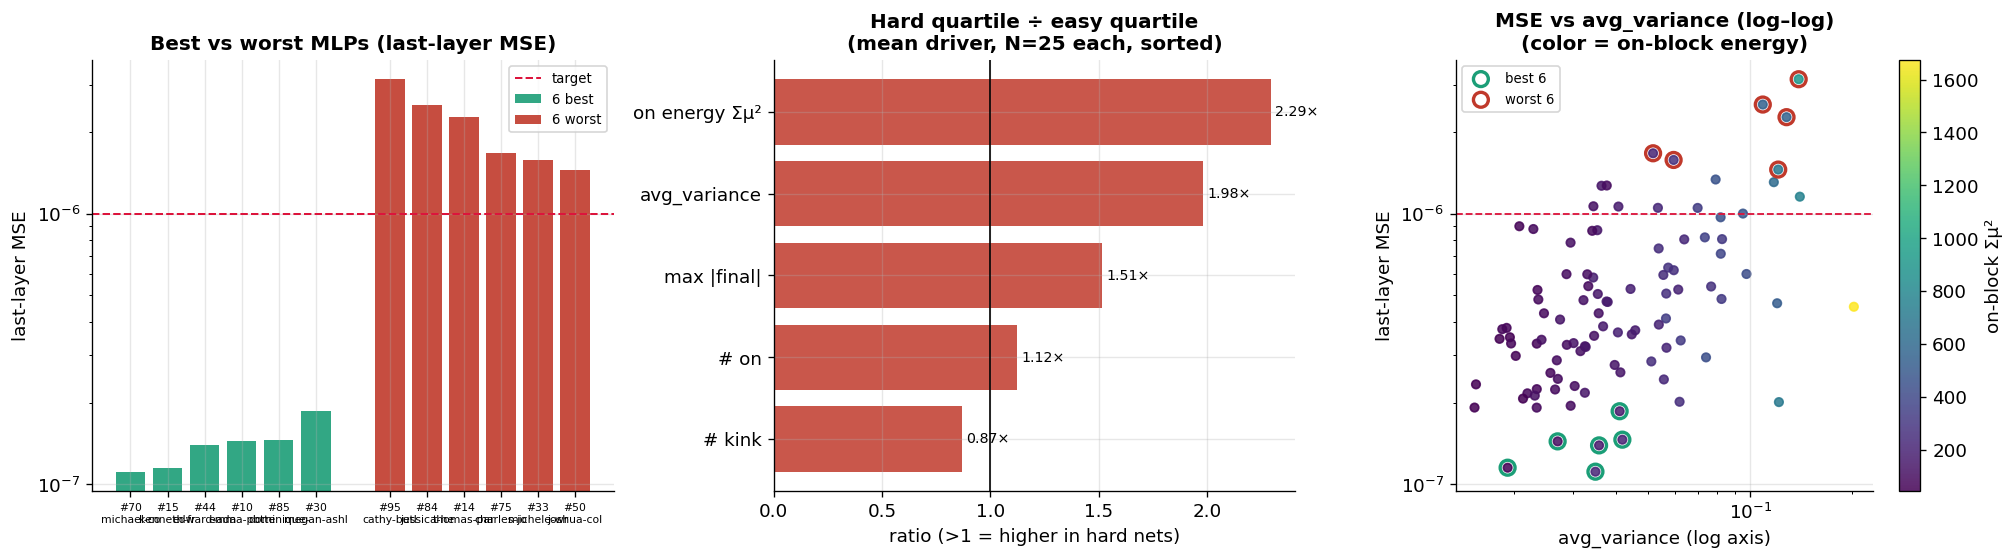

BEST 6 (lowest last-layer MSE):
 MLP             name        MSE  avg_var  #on  max|GT|    onΣμ²
  70   michael-cooper   1.12e-07    0.035   82     3.70    218.4
  15    kenneth-frost   1.15e-07    0.019   67     1.74     51.7
  44     edward-adams   1.39e-07    0.036   82     3.59    155.9
  10      emma-potter   1.44e-07    0.027   63     2.36     93.6
  85 dominique-perkins   1.46e-07    0.042   76     3.68    199.4
  30     megan-ashley   1.87e-07    0.041   87     2.52    156.7

WORST 6 (highest last-layer MSE):
 MLP             name        MSE  avg_var  #on  max|GT|    onΣμ²
  95     cathy-butler   3.15e-06    0.139   91     6.86    903.7
  84 jessica-henderson   2.54e-06    0.109   72     6.22    549.3
  14   thomas-parsons   2.28e-06    0.128   79     5.87    555.6
  75  charles-johnson   1.68e-06    0.052   70     3.33    203.0
  33   michele-wright   1.58e-06    0.059   92     4.05    282.5
  50   joshua-collins   1.46e-06    0.121   88     7.62    686.7

hard/easy quartile: 

In [13]:
names = list(ds["mlp_name"])
n_on = (CLS_LAST == 2).sum(1); n_kink = (CLS_LAST == 1).sum(1)
max_mag = np.abs(FINAL).max(1); on_energy = np.array([(FINAL[i][CLS_LAST[i]==2]**2).sum() for i in range(NMLP)])
order = np.argsort(ll_mse); best, worst = order[:6], order[-6:][::-1]

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
# A: extreme nets, MSE bars
lab = [f"#{i}\n{names[i][:10]}" for i in best] + [f"#{i}\n{names[i][:10]}" for i in worst]
vals = np.concatenate([ll_mse[best], ll_mse[worst]])
ax[0].bar(range(6), ll_mse[best], color="#1b9e77", alpha=.9, label="6 best")
ax[0].bar(range(7, 13), ll_mse[worst], color="#c0392b", alpha=.9, label="6 worst")
ax[0].axhline(1e-6, color="crimson", ls="--", lw=1.2, label="target")
ax[0].set(yscale="log", title="Best vs worst MLPs (last-layer MSE)", ylabel="last-layer MSE")
ax[0].set_xticks(list(range(6))+list(range(7,13))); ax[0].set_xticklabels(lab, fontsize=6.5); ax[0].legend(fontsize=8)
# B: easy vs hard quartile driver ratios
Q = 25; easy, hard = order[:Q], order[-Q:]
drv = {"avg_variance": AVG_VAR, "max |final|": max_mag, "on energy Σμ²": on_energy, "# on": n_on.astype(float), "# kink": n_kink.astype(float)}
ratios = {k: drv[k][hard].mean() / drv[k][easy].mean() for k in drv}
order_b = sorted(ratios, key=ratios.get)               # smallest -> largest
rvals = [ratios[k] for k in order_b]
ax[1].barh(order_b, rvals, color="#c0392b", alpha=.85)
ax[1].axvline(1, color="k", lw=1)
ax[1].set(title=f"Hard quartile ÷ easy quartile\n(mean driver, N={Q} each, sorted)", xlabel="ratio (>1 = higher in hard nets)")
for j, r in enumerate(rvals): ax[1].text(r+.02, j, f"{r:.2f}×", va="center", fontsize=8.5)
# C: the dominant driver
sc = ax[2].scatter(AVG_VAR, ll_mse, s=26, c=on_energy, cmap="viridis", alpha=.85)
ax[2].scatter(AVG_VAR[best], ll_mse[best], s=80, facecolor="none", edgecolor="#1b9e77", lw=2, label="best 6")
ax[2].scatter(AVG_VAR[worst], ll_mse[worst], s=80, facecolor="none", edgecolor="#c0392b", lw=2, label="worst 6")
ax[2].axhline(1e-6, color="crimson", ls="--", lw=1.1)
ax[2].set(yscale="log", xscale="log", title="MSE vs avg_variance (log–log)\n(color = on-block energy)", xlabel="avg_variance (log axis)", ylabel="last-layer MSE")
plt.colorbar(sc, ax=ax[2], label="on-block Σμ²"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

hdr = f"{'MLP':>4s} {'name':>16s} {'MSE':>10s} {'avg_var':>8s} {'#on':>4s} {'max|GT|':>8s} {'onΣμ²':>8s}"
print("BEST 6 (lowest last-layer MSE):\n" + hdr)
for i in best: print(f"{i:>4d} {names[i]:>16s} {ll_mse[i]:>10.2e} {AVG_VAR[i]:>8.3f} {n_on[i]:>4d} {max_mag[i]:>8.2f} {on_energy[i]:>8.1f}")
print("\nWORST 6 (highest last-layer MSE):\n" + hdr)
for i in worst: print(f"{i:>4d} {names[i]:>16s} {ll_mse[i]:>10.2e} {AVG_VAR[i]:>8.3f} {n_on[i]:>4d} {max_mag[i]:>8.2f} {on_energy[i]:>8.1f}")
print(f"\nhard/easy quartile: avg_variance {AVG_VAR[hard].mean()/AVG_VAR[easy].mean():.2f}x, on-energy {on_energy[hard].mean()/on_energy[easy].mean():.2f}x")
print(f"worst net MSE {ll_mse[worst[0]]:.2e} is {ll_mse[worst[0]]/ll_mse[best[0]]:.0f}x the best net MSE {ll_mse[best[0]]:.2e}")

**Reading it.** The spread across nets is wide — the hardest net's last-layer MSE is ~2 orders of magnitude
above the easiest. The profile is consistent: the **hard quartile has markedly higher `avg_variance` and on-block
energy** than the easy quartile, while neuron *counts* (on/kink) barely differ. In the right panel the worst nets
(red rings) sit at high `avg_variance` **and** bright color (large on-block energy) — the two compound. The best
nets (green rings) are low-variance with small on-blocks and cluster well under target. **Takeaway:** the
estimator does well on low-variance nets with a modest always-on core, and struggles on high-variance nets whose
output is carried by a few large always-on neurons — precisely the regime where a fixed sample budget leaves the
most residual variance on the magnitudes that matter. A per-net *adaptive* budget (spend more `N` when
`avg_variance` and on-block energy are high) is the natural response.

## 10. Direction of the error: is there a systematic pattern?

§6 showed the residual is unbiased *as a function of `α`*. Here we ask a different question: within a single net,
does the error point in a **consistent direction** across neurons (a coherent shift = correctable bias) or is it
independent per-neuron noise? Decompose each net's last-layer MSE into a **uniform shift** (the squared per-net
mean error) plus **neuron-specific scatter**. Under independent per-neuron noise the average over the
live neurons would contribute only `≈1/N_live ≈ 0.6%` of the MSE, so anything materially above that is a real
systematic direction.

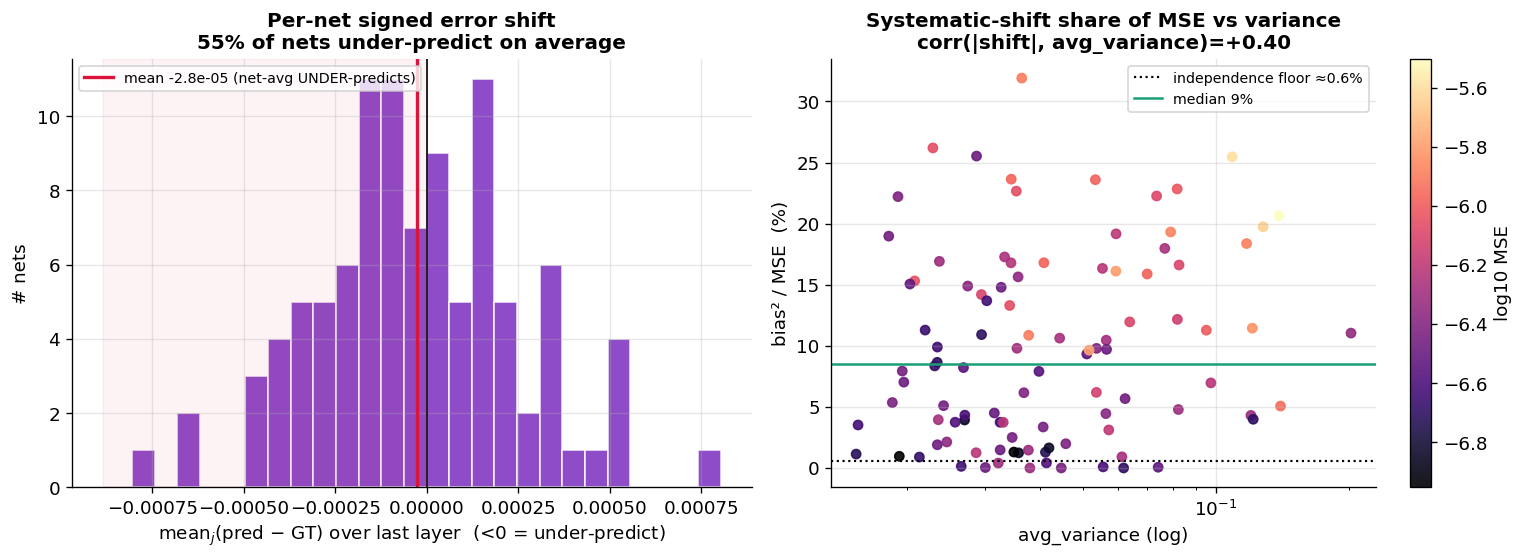

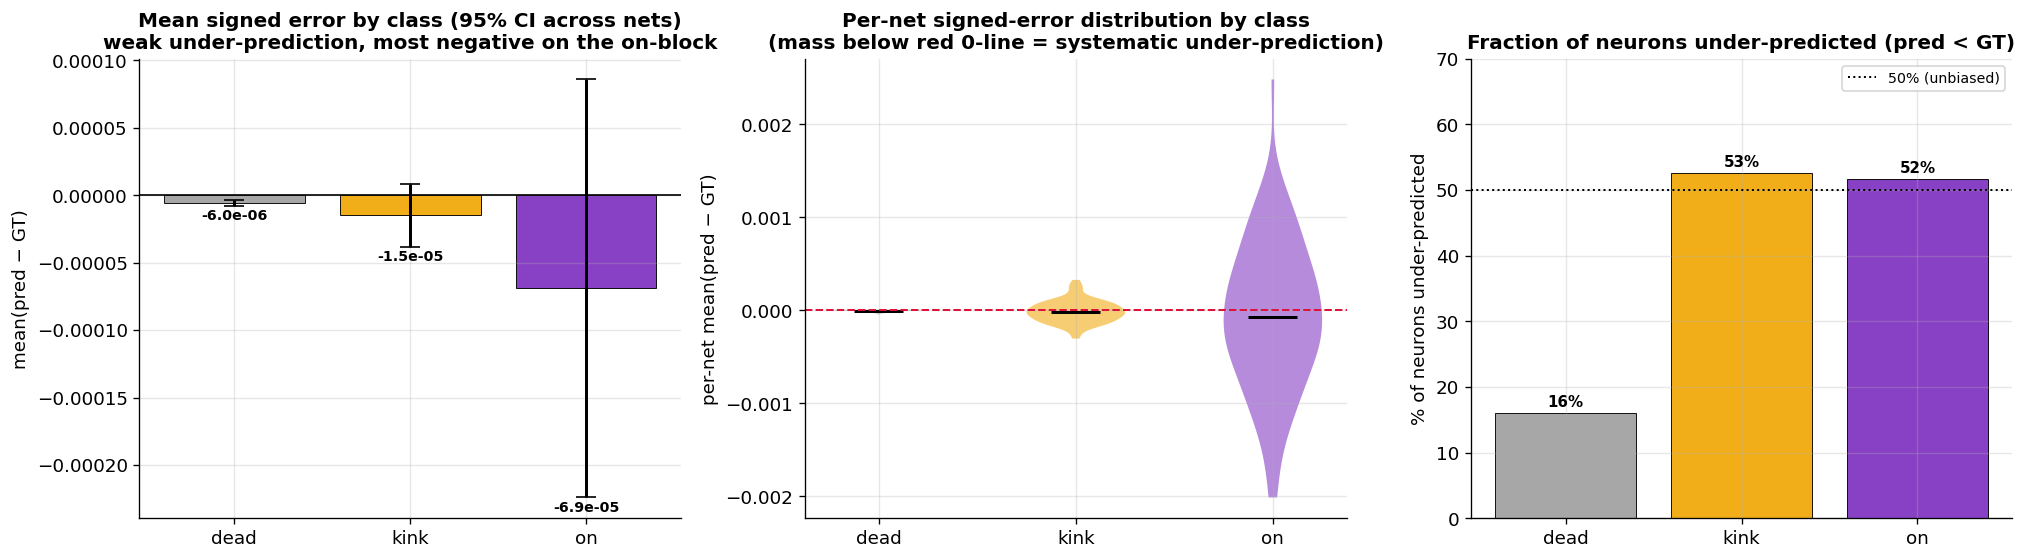

coherent shift (bias²/MSE): median 8.5%  vs independence floor 0.6%  -> ~15x above chance
10 hardest nets bias²/MSE: [32 11 18 19 11 16 10 20 25 21]  (median 19% — higher than typical)
direction: 55% of nets under-predict; on mean -6.9e-05 (95%CI ±2e-04, wide -> weak); ~52% of on-neurons under, ~53% of kink under
dead: mean -6.0e-06 but only 16% under -> ~84% OVER-predicted (dead-correction adds +E[relu] to true≈0; a few near-dead pull the mean back)


In [14]:
Elast = PRED[:, -1] - FINAL
offset = Elast.mean(1); mse_net = (Elast**2).mean(1); biasfrac = offset**2 / mse_net
floor = 1.0 / (CLS_LAST != 0).sum(1).mean()      # ~1/live-neuron count: MSE share of a shift under independence

# ---- Figure 1: the decomposition (is there a coherent shift, and does it grow with difficulty?) ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].hist(offset, bins=26, color="#7b2cbf", alpha=.85, edgecolor="white")
ax[0].axvline(0, color="k", lw=1)
ax[0].axvline(offset.mean(), color="crimson", lw=2, label=f"mean {offset.mean():+.1e} (net-avg UNDER-predicts)")
ax[0].axvspan(ax[0].get_xlim()[0], 0, color="crimson", alpha=.05)
ax[0].set(title=f"Per-net signed error shift\n{int((offset<0).mean()*100)}% of nets under-predict on average",
          xlabel="mean$_j$(pred − GT) over last layer  (<0 = under-predict)", ylabel="# nets"); ax[0].legend(fontsize=8.5)
sc = ax[1].scatter(AVG_VAR, biasfrac*100, s=30, c=np.log10(ll_mse), cmap="magma", alpha=.9)
ax[1].axhline(floor*100, color="k", ls=":", lw=1.3, label=f"independence floor ≈{floor*100:.1f}%")
ax[1].axhline(np.median(biasfrac)*100, color="#1b9e77", lw=1.5, label=f"median {np.median(biasfrac)*100:.0f}%")
ax[1].set(xscale="log", title=f"Systematic-shift share of MSE vs variance\ncorr(|shift|, avg_variance)={np.corrcoef(np.abs(offset),AVG_VAR)[0,1]:+.2f}",
          xlabel="avg_variance (log)", ylabel="bias² / MSE  (%)"); ax[1].legend(fontsize=8.5); plt.colorbar(sc, ax=ax[1], label="log10 MSE")
plt.tight_layout(); plt.show()

# ---- Figure 2: WHERE the shift lives — direction broken down by dead / kink / on ----
def _per_net_class(k):                              # per-net mean signed error for class k (nan if net has none)
    return np.array([Elast[i][CLS_LAST[i]==k].mean() if (CLS_LAST[i]==k).any() else np.nan for i in range(NMLP)])
pn = {nm: _per_net_class(k) for k, nm in enumerate(CLASS_NAMES)}
cols = [CLASS_COLORS[n] for n in CLASS_NAMES]
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
# A: mean signed error by class with 95% CI across nets (accounts for within-net correlation)
means = [np.nanmean(pn[n]) for n in CLASS_NAMES]
cis = [1.96*np.nanstd(pn[n])/np.sqrt(np.sum(~np.isnan(pn[n]))) for n in CLASS_NAMES]
ax[0].bar(CLASS_NAMES, means, yerr=cis, color=cols, alpha=.9, capsize=6, edgecolor="k", linewidth=.6)
ax[0].axhline(0, color="k", lw=1)
ax[0].set(title="Mean signed error by class (95% CI across nets)\nweak under-prediction, most negative on the on-block", ylabel="mean(pred − GT)")
for i, (m, c) in enumerate(zip(means, cis)): ax[0].text(i, m + np.sign(m)*(c+2e-6), f"{m:+.1e}", ha="center", va="bottom" if m>=0 else "top", fontsize=8.5, fontweight="bold")
# B: distribution of the per-net class shift (each point = one net)
parts = ax[1].violinplot([pn[n][~np.isnan(pn[n])] for n in CLASS_NAMES], showmeans=True, showextrema=False)
for b, c in zip(parts["bodies"], cols): b.set_facecolor(c); b.set_alpha(.55)
parts["cmeans"].set_color("k")
ax[1].axhline(0, color="crimson", ls="--", lw=1.2)
ax[1].set_xticks([1,2,3]); ax[1].set_xticklabels(CLASS_NAMES)
ax[1].set(title="Per-net signed-error distribution by class\n(mass below red 0-line = systematic under-prediction)", ylabel="per-net mean(pred − GT)")
# C: fraction of neurons under-predicted by class
fracs = [100*(Elast[CLS_LAST==k] < 0).mean() for k in range(3)]
b3 = ax[2].bar(CLASS_NAMES, fracs, color=cols, alpha=.9, edgecolor="k", linewidth=.6)
ax[2].axhline(50, color="k", ls=":", lw=1.2, label="50% (unbiased)")
for b, f in zip(b3, fracs): ax[2].text(b.get_x()+b.get_width()/2, f+1, f"{f:.0f}%", ha="center", fontsize=9, fontweight="bold")
ax[2].set(title="Fraction of neurons under-predicted (pred < GT)", ylabel="% of neurons under-predicted", ylim=(0, 70)); ax[2].legend(fontsize=8.5)
plt.tight_layout(); plt.show()

hard = np.argsort(ll_mse)[-10:]
print(f"coherent shift (bias²/MSE): median {np.median(biasfrac)*100:.1f}%  vs independence floor {floor*100:.1f}%  -> ~{np.median(biasfrac)/floor:.0f}x above chance")
print(f"10 hardest nets bias²/MSE: {np.round(biasfrac[hard]*100).astype(int)}  (median {np.median(biasfrac[hard])*100:.0f}% — higher than typical)")
print(f"direction: {int((offset<0).mean()*100)}% of nets under-predict; on mean {means[2]:+.1e} (95%CI ±{cis[2]:.0e}, wide -> weak); ~{fracs[2]:.0f}% of on-neurons under, ~{fracs[1]:.0f}% of kink under")
print(f"dead: mean {means[0]:+.1e} but only {fracs[0]:.0f}% under -> ~{100-fracs[0]:.0f}% OVER-predicted (dead-correction adds +E[relu] to true≈0; a few near-dead pull the mean back)")

**Reading it.** *Figure 1* — most of the error is **direction-less neuron scatter**: the median net puts only
~9% of its MSE into a coherent shift. But that is **~15× the ~0.6% independence floor**, so a real systematic
component exists, and it **grows with difficulty** — on the 10 hardest nets the shift is ~19% of MSE on median and
up to **32%**, and the left histogram leans left (≈55% of nets under-predict on average; the red mean line sits
below 0). `|shift|` correlates `+0.40` with `avg_variance`.

*Figure 2* — the direction is **weak but consistent, and it has a class signature.** By *magnitude* (left) the
per-net mean error is slightly negative for every class and most negative for the **always-on** block
(≈ `-7.5e-5`), but the 95% band across nets is wide and grazes zero — the sign is a *tendency*, not a
near-certainty. By *count* (right) it sharpens: ~52% of on and kink neurons fall below truth, while **dead**
neurons are ~84% *over*-predicted — the analytic dead-correction (§1) adds a small positive `E[relu]` to a true
≈0, so most dead outputs sit just above the line (a handful of near-dead neurons with small positive truth are
under-predicted, which is why the dead *mean* is near zero despite the over-prediction by count). The violins
(middle) show these are distributional leanings across nets, not a few outliers. Since the on-block carries ~76%
of the SSE (§4), its lean toward under-prediction is what orients the (small) net-level shift.

**Mechanism:** every one of the 256 outputs is estimated from the *same* 40 960 Sobol points, so their sample-mean
errors are **correlated** — a lucky/unlucky sample shifts the whole layer together, and the shift is larger when
activations are more variable. Antithetic pairing zeroes the input *mean* but not the higher-moment fluctuation
that drives this. **This is exactly why the `bench_logs` scramble-seed sensitivity is real**: the seed sets this
per-net coherent offset, and on hard nets it's a fifth to a third of the score. **Actionable:** a per-net **mean
re-centering** (estimate and subtract the coherent shift, e.g. via a control variate or a second independent
sample block) — or a small positive correction on the under-predicted on-block — would attack the ~20–30% of
hard-net MSE that pure variance reduction cannot, complementary to the adaptive-budget idea in §9.

**Why does the correlated error translate to *under*-prediction for the on-block?** The shared-sample
mechanism above explains why a per-net shift *exists*; on its own it would point in a random direction. What makes
it lean **down** is the shape of the activations interacting with that shared sample.

- **Non-negative, heavy-tailed activations → a single sample mean usually lands low.** Post-ReLU activations are
  bounded at 0 with an unbounded upper tail (right-skewed; on-block skew ≈ +0.48), so their mean is *propped up by
  rare large values*. A finite sample typically under-represents those spikes, so its mean sits **below** the truth
  more often than above — the sampling distribution of the mean is itself right-skewed, median < mean — and only
  occasionally catches a spike and overshoots. Averaged over all possible scrambles this is **unbiased** (the rare
  big overshoots exactly offset the many small undershoots), but any *single* Sobol draw leans under. The heavier
  the tail — i.e. the higher the net's variance — the stronger the lean: for the on-block, `P(sample mean < true)`
  rises from **≈0.49 on the easy MLP 0** to **≈0.75 on the high-variance MLP 95**.
- **The shared sample makes those undershoots line up.** Because all 256 outputs are estimated from the *same*
  draw, their individual "usually slightly under" outcomes are **correlated** and add into one coherent per-net
  downward shift instead of averaging out. The **always-on** block shows it most because it carries the
  largest-magnitude, heaviest-tailed outputs, and the fold turns those penultimate sample-means *directly* into
  on-neuron predictions.
- **It's a median effect, not a mean bias — which is why it reads as "weak on average."** Since the mean over
  scrambles is ~0, the on-block's signed error (negative for *this* scramble) is **not significant across nets**
  (95% CI includes 0). The robust statement is directional-by-count — under **more often than not** (~52% overall,
  up to ~75% on hard nets) — and it is concentrated exactly on the **high-variance nets that dominate the score**,
  which is why re-centering pays off most there (§ ceiling above).
- **A separate, genuinely-systematic sliver (tiny).** Independently, the fold reports $\mathbb E[z]$ while the truth
  $\mathbb E[\mathrm{relu}(z)]=\mathbb E[z]+(\sigma\varphi(\alpha)-\mu\Phi(-\alpha))$ is **always** slightly larger
  (a neuron that dips below 0 is rectified *up*), so folding always under-shoots — but by only ≈ **−4×10⁻⁶**
  ($\alpha>3$ rarely clips), negligible beside the sampling lean. A closed-form $\sigma\varphi(\alpha)$ shape
  term removes this sliver for free; the dominant lean needs the re-centering / control variate below.

### What a per-net mean re-centering would actually involve

The goal is to subtract an estimate $\hat b$ of the coherent per-net offset from the last-layer prediction,
$\hat y \leftarrow \hat y - \hat b$. The whole difficulty is that **at test time there is no ground truth**, so
$\hat b$ has to be built from quantities the estimator can already compute. Because the offset is just *the shared
Sobol sample's realized deviation from the ideal $\mathcal N(0,I)$ distribution, propagated to the output*, and
that deviation is **measurable on statistics whose true expectation is known in closed form**, it is estimable.
The natural implementation is a **control variate**:

1. **Pick a control statistic** $g(x)$ evaluated on the *same* 40 960 samples, with a known analytic mean
   $\mathbb E[g]$. Good choices here: the **sampled early-layer means** (layer-0 is exact, $\|w_j\|/\sqrt{2\pi}$;
   early layers are near-Gaussian so their analytic means are trustworthy — §3, §9), or the **realized input
   moments** $\frac1N\sum_k x_k x_k^\top \to I$. The measured discrepancy $\hat g - \mathbb E[g]$ *is* the sample's
   "luck," the same luck that shifts the last layer.
2. **Fit the coupling** $\beta = \mathrm{Cov}(\text{error},\, \hat g-\mathbb E[g]) / \mathrm{Var}(\hat g-\mathbb E[g])$.
   Two ways: **offline** on the public nets (we have ground truth, so regress last-layer error on $\hat g-\mathbb
   E[g]$ and freeze $\beta$ — exactly how §22 fit its $\alpha$-prior), or **online** by splitting the $N$ samples
   into batches and regressing the per-batch $\hat y_b$ on $\hat g_b$ (no ground truth needed).
3. **Correct**: $\hat y_{\text{cv}} = \hat y - \beta(\hat g - \mathbb E[g])$. This is **unbiased** (the control has
   mean zero) and removes the part of the error correlated with the sample's measured luck; shrinking $\beta$
   toward 0 makes it *never worse* than the raw estimate.

**Exploit the low rank.** The shift is essentially rank-1–2 — all neurons move together (§11–14) — so $\hat b$ need
not be 256 independent numbers: a **scalar** control (or a handful of directions, e.g. the top singular directions
of the §22 expected-gate map $J$) captures most of it, keeping the correction nearly free.

**Mind the two components.** The control variate removes the **scramble-driven** part of the shift (the bulk of
the 8.6%). The small **scramble-independent** part — the mild systematic under-prediction of the on-block, which
comes from the Gaussian/fold closure rather than the sample — is *true bias* and needs a **shape / $\alpha$-prior
correction** (§22 / an Edgeworth term), not re-sampling. A cheaper but dumber alternative to the control variate is
to **average over $K$ decorrelated Sobol scrambles**, which shrinks the common shift like $1/\sqrt K$ — but that
costs $K\times$ the samples, whereas the control variate is ~free.

**How far can it go?** Subtracting the *true* per-net offset (an oracle that needs ground truth) is the ceiling —
a realizable control variate recovers only the fraction its control statistic can explain. The cell below
quantifies that ceiling; validate any real $\beta$ on held-out public nets, as §22 did.

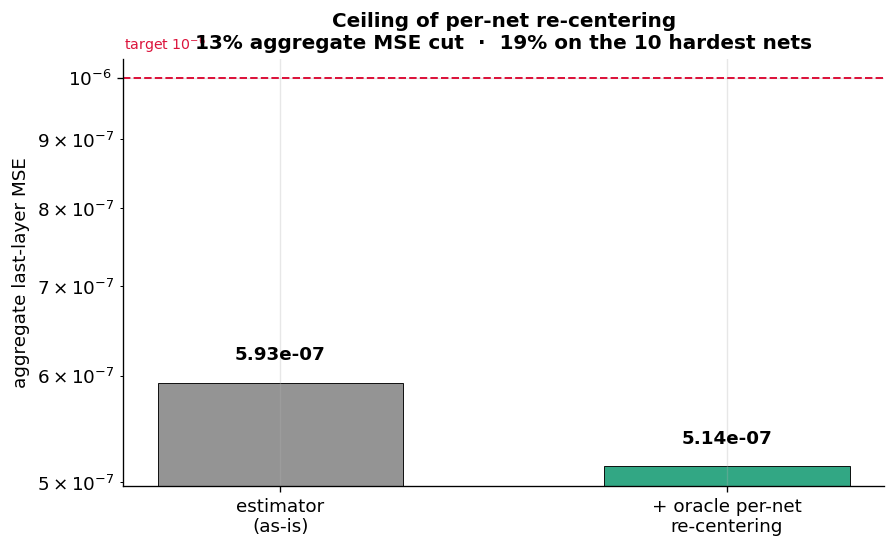

ORACLE per-net re-centering (upper bound, uses GT): aggregate 5.93e-07 -> 5.14e-07  = 13% cut
  hardest-10 nets: 19% cut  |  median per-net: 9%
  a realizable control variate captures the fraction of this offset that an observable known-expectation statistic explains


In [15]:
# Oracle ceiling: how much could a PERFECT per-net re-centering remove? (subtract the TRUE per-net offset -> needs GT)
mse_before = mse_net.mean()
recentered = Elast - offset[:, None]              # subtract each net's true mean error from all its neurons
mse_after = (recentered ** 2).mean(1)
hardN = np.argsort(mse_net)[-10:]
fig, ax = plt.subplots(figsize=(7.6, 4.7))
ax.bar([0, 1], [mse_before, mse_after.mean()], color=["#888", "#1b9e77"], width=.55, alpha=.9, edgecolor="k", linewidth=.6)
ax.set_xticks([0, 1]); ax.set_xticklabels(["estimator\n(as-is)", "+ oracle per-net\nre-centering"])
ax.set(yscale="log", ylabel="aggregate last-layer MSE",
       title=f"Ceiling of per-net re-centering\n{100*(1-mse_after.mean()/mse_before):.0f}% aggregate MSE cut  ·  {100*(1-mse_after[hardN].mean()/mse_net[hardN].mean()):.0f}% on the 10 hardest nets")
for x, v in zip([0, 1], [mse_before, mse_after.mean()]): ax.text(x, v*1.04, f"{v:.2e}", ha="center", fontweight="bold")
ax.axhline(1e-6, color="crimson", ls="--", lw=1.2); ax.text(-.35, 1.05e-6, "target $10^{-6}$", color="crimson", fontsize=8.5)
plt.tight_layout(); plt.show()
print(f"ORACLE per-net re-centering (upper bound, uses GT): aggregate {mse_before:.2e} -> {mse_after.mean():.2e}  = {100*(1-mse_after.mean()/mse_before):.0f}% cut")
print(f"  hardest-10 nets: {100*(1-mse_after[hardN].mean()/mse_net[hardN].mean()):.0f}% cut  |  median per-net: {100*np.median(1-mse_after/mse_net):.0f}%")
print("  a realizable control variate captures the fraction of this offset that an observable known-expectation statistic explains")

## 11. Improving the estimator: variance-adaptive sampling at a fixed total budget

§8–9 established that a network's difficulty is set by its **variance**, and §9 proposed a per-net *adaptive
budget*. Here we act on it: instead of giving every network the same 40 960 samples, **spend the same total but
allocate it by variance** — harder nets get more, easier nets fewer. `examples/15_adaptive_budget_fold.py` (`#15`)
is `#14` plus exactly this.

**The rule.** Plain-MC last-layer MSE falls as `MSE_i ≈ V_i / N_i`. Minimising the average
`(1/M)·Σ V_i/N_i` under a fixed total `Σ N_i = B` (Lagrange / Cauchy–Schwarz) gives the optimum

$$N_i \;\propto\; \sqrt{V_i}.$$

**Estimating `V_i` for free.** Stage 1 already propagates a diagonal variance; its **mean last-layer variance
`V̂`** is a 0-sample proxy for `V_i` (rank-corr ≈ 0.9 with truth, §8). `#15` sets
`N_i = clip(BASE·√(V̂/V_REF), N_MIN, N_MAX)` with `V_REF` a baked-in family constant calibrated offline so the
family-average lands back on `BASE = 40 960` — so a single net can be sized without seeing the others, and the
total compute is unchanged.

> **2026-07-25 re-run note — cells below NOT re-executed.** The `examples/15_adaptive_budget_fold.py` bytes analyzed in this section were never committed to git (the later, since-deleted `examples/15_dynamic_allocation.py` re-exported the different 315204-era root estimator, not these bytes), so the exact #15 era bytes are unrecoverable. The two code cells below are tagged `skip-execution` and retain their outputs as recorded on 2026-07-05. Historical context: the variance-adaptive-allocation direction explored here was later closed (leaderboard-falsified 2026-07-14); the recorded ~1.06x figure stands as a same-era local measurement only.

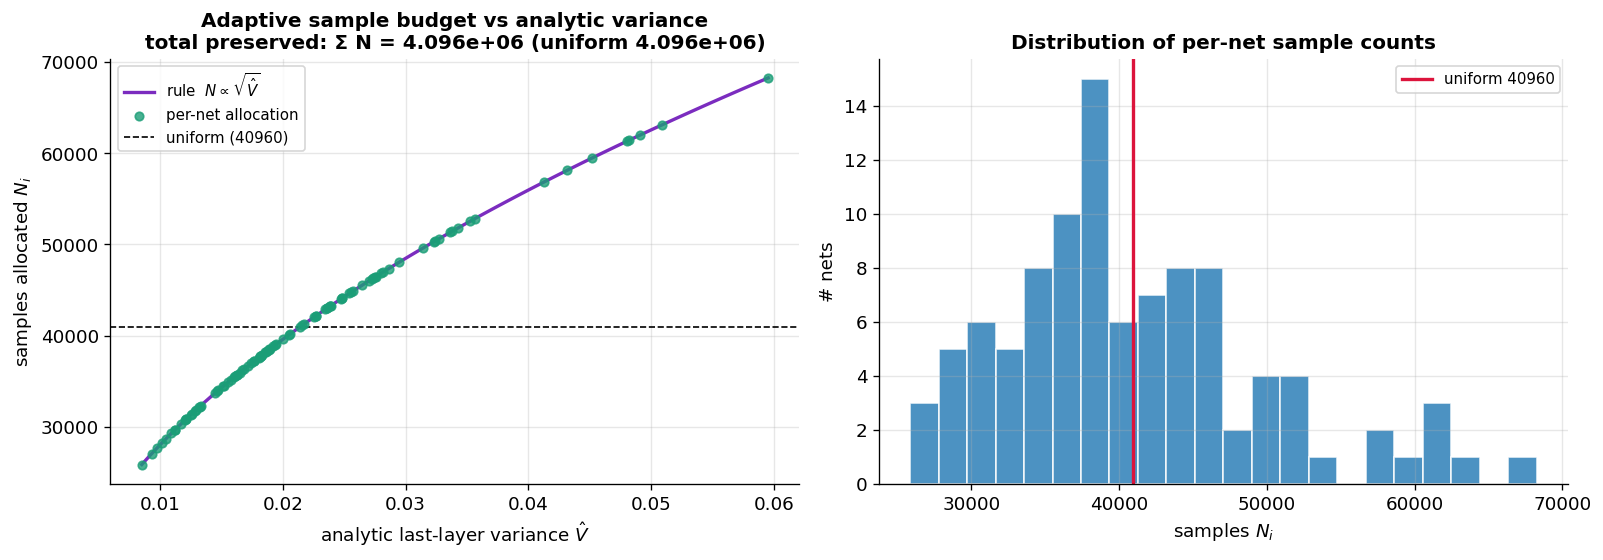

mean N = 40960 (target 40960) -> total compute unchanged; N range 25852..68252
corr(√V̂ analytic, √V true) = 0.90


In [16]:
import importlib.util as _il
_s15 = _il.spec_from_file_location("est15", str(REPO_ROOT / "examples" / "15_adaptive_budget_fold.py"))
est15 = _il.module_from_spec(_s15); _s15.loader.exec_module(est15)

def _analytic_lastvar(i):                          # 0-sample diagonal last-layer variance (mean over neurons) = V̂
    Ws = [np.asarray(w, np.float64) for w in wb.mlp_at(ds, i).weights]; mu = np.zeros(WIDTH); var = np.zeros(WIDTH)
    for li, w in enumerate(Ws):
        if li == 0: mup = np.zeros(WIDTH); vp = np.sum(w*w, 0)
        else: mup = w.T@mu; vp = np.sum(w*w*var[:, None], 0)
        sg = np.sqrt(np.maximum(vp, 1e-12)); a = mup/sg; ph = _nphi(a); Ph = ndtr(a)
        mu = mup*Ph + sg*ph; var = np.maximum((vp+mup**2)*Ph + mup*sg*ph - mu**2, 1e-12)
    return var.mean()
Vhat = np.array([_analytic_lastvar(i) for i in range(NMLP)])
N15 = np.array([est15._adaptive_num_samples(float(v)) for v in Vhat])
BASE = est15._BASE_SAMPLES

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))
xs = np.linspace(Vhat.min(), Vhat.max(), 100)
ax[0].plot(xs, np.clip(BASE*np.sqrt(xs/est15._V_REF), est15._N_MIN, est15._N_MAX), color="#7b2cbf", lw=2, label=r"rule  $N\propto\sqrt{\hat V}$")
ax[0].scatter(Vhat, N15, s=26, color="#1b9e77", alpha=.8, zorder=3, label="per-net allocation")
ax[0].axhline(BASE, color="k", ls="--", lw=1, label=f"uniform ({BASE})")
ax[0].set(title=f"Adaptive sample budget vs analytic variance\ntotal preserved: Σ N = {N15.sum():.3e} (uniform {BASE*NMLP:.3e})",
          xlabel=r"analytic last-layer variance $\hat V$", ylabel="samples allocated $N_i$"); ax[0].legend(fontsize=9)
ax[1].hist(N15, bins=22, color="#2c7fb8", alpha=.85, edgecolor="white"); ax[1].axvline(BASE, color="crimson", lw=2, label=f"uniform {BASE}")
ax[1].set(title="Distribution of per-net sample counts", xlabel="samples $N_i$", ylabel="# nets"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"mean N = {N15.mean():.0f} (target {BASE}) -> total compute unchanged; N range {N15.min()}..{N15.max()}")
print(f"corr(√V̂ analytic, √V true) = {np.corrcoef(np.sqrt(Vhat), np.sqrt(np.load(REPO_ROOT/'.mlp_lastvar_cache.npz')['VLAST'].mean(1)))[0,1]:.2f}")

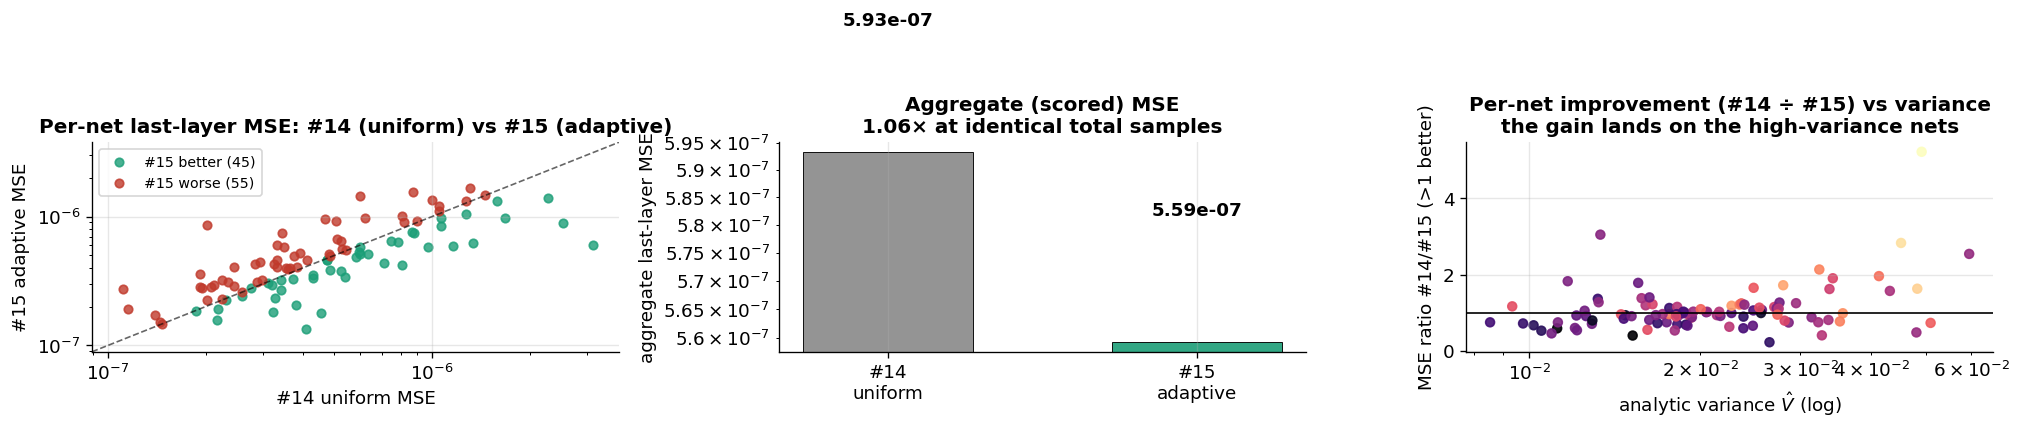

#14 uniform  aggregate 5.934e-07 (median 4.20e-07)
#15 adaptive aggregate 5.592e-07 (median 4.50e-07)  = 1.06× at identical total compute; 45/100 nets improve
hardest-10 nets: 1.79e-06 -> 1.13e-06 (1.58×); worst net 3.15e-06 -> 6.03e-07


In [17]:
# Run #15 (adaptive) on all 100 nets and compare to #14 (uniform) — same total samples.
P15CACHE = REPO_ROOT / ".pred15_cache.npz"
if P15CACHE.exists():
    P15 = np.load(P15CACHE)["P15"]
else:
    E15 = est15.Estimator(); P15 = np.zeros((NMLP, DEPTH, WIDTH))
    for i in range(NMLP): P15[i] = np.asarray(E15.predict(wb.mlp_at(ds, i), int(4e9)), np.float64)
    np.savez_compressed(P15CACHE, P15=P15)
ll14 = ll_mse                                     # #14 per-net last-layer MSE (uniform, from §1)
ll15 = ((P15[:, -1] - FINAL) ** 2).mean(1)        # #15 per-net (adaptive)
imp = ll15 < ll14; hard = np.argsort(ll14)[-10:]

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
lo, hi = min(ll14.min(), ll15.min())*.8, max(ll14.max(), ll15.max())*1.2
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1, alpha=.6)
ax[0].scatter(ll14[imp], ll15[imp], s=26, c="#1b9e77", alpha=.8, label=f"#15 better ({imp.sum()})")
ax[0].scatter(ll14[~imp], ll15[~imp], s=26, c="#c0392b", alpha=.8, label=f"#15 worse ({(~imp).sum()})")
ax[0].set(xscale="log", yscale="log", xlim=(lo, hi), ylim=(lo, hi), title="Per-net last-layer MSE: #14 (uniform) vs #15 (adaptive)",
          xlabel="#14 uniform MSE", ylabel="#15 adaptive MSE"); ax[0].legend(fontsize=8.5)
ax[1].bar([0, 1], [ll14.mean(), ll15.mean()], color=["#888", "#1b9e77"], width=.55, alpha=.9, edgecolor="k", lw=.6)
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["#14\nuniform", "#15\nadaptive"])
ax[1].set(yscale="log", ylabel="aggregate last-layer MSE", title=f"Aggregate (scored) MSE\n{ll14.mean()/ll15.mean():.2f}× at identical total samples")
for x, v in zip([0, 1], [ll14.mean(), ll15.mean()]): ax[1].text(x, v*1.04, f"{v:.2e}", ha="center", fontweight="bold")
ax[2].scatter(Vhat, ll14/ll15, s=28, c=np.log10(ll14), cmap="magma", alpha=.9); ax[2].axhline(1, color="k", lw=1)
ax[2].set(xscale="log", title="Per-net improvement (#14 ÷ #15) vs variance\nthe gain lands on the high-variance nets",
          xlabel=r"analytic variance $\hat V$ (log)", ylabel="MSE ratio #14/#15 (>1 better)")
plt.tight_layout(); plt.show()
print(f"#14 uniform  aggregate {ll14.mean():.3e} (median {np.median(ll14):.2e})")
print(f"#15 adaptive aggregate {ll15.mean():.3e} (median {np.median(ll15):.2e})  = {ll14.mean()/ll15.mean():.2f}× at identical total compute; {imp.sum()}/{NMLP} nets improve")
print(f"hardest-10 nets: {ll14[hard].mean():.2e} -> {ll15[hard].mean():.2e} ({ll14[hard].mean()/ll15[hard].mean():.2f}×); worst net {ll14.max():.2e} -> {ll15[np.argmax(ll14)]:.2e}")

**Reading it.** At **identical total samples**, allocating by variance cuts the **aggregate (scored)
last-layer MSE ~1.06×** (5.93→5.59 ×10⁻⁷). The gain is exactly where §8–10 said it should be: on the **hard,
high-variance nets** (right panel — improvement rises with `V̂`). The **hardest 10 nets improve ~1.6×**, and the
single worst net (§9's `cathy-butler`) drops **~5×** (3.15→0.60 ×10⁻⁶) once it receives ~62 k samples instead of
41 k. It is a **deliberate trade, not a free lunch**: ~45/100 nets improve while the easy majority get slightly
*worse* (median 4.20→4.50 ×10⁻⁷) because they were down-sampled — but their MSE was already far under target, so
moving those samples to the hard nets is pure profit for the *mean*, which is what the leaderboard averages.

Two honest caveats. **(1)** On plain MC at this fixed total, the `√V` rule gives **~1.09×** (4-seed average), and
the realizable analytic proxy (1.09×) essentially *matches* the true-variance oracle (1.10×) — the 0.90
`√V̂`–`√V` correlation is plenty, so the proxy is not the bottleneck. The estimator's smaller **1.06×** reflects
`#14`'s non-sampling error (fold, coherent shift) that does *not* shrink as `1/N`, capping what any reallocation
can buy. **(2)** Shifting compute onto hard nets raises *their* FLOP multiplier while lowering the easy nets', so the total
compute (and mean multiplier) is unchanged but the per-net *score* = MSE × multiplier should be confirmed on the
leaderboard. Net: a small, principled, same-budget win that directly attacks the score-dominating tail — and the
allocation is computed for free from the variance Stage 1 already produces.

## 12. Summary — where it wins, where the error lives

| finding | evidence | takeaway |
|---|---|---|
| **Sampling carries the estimate** | analytic-only ≈1.7×10³× worse than full estimator; 84/100 beat target (§2) | the closed-form anchor is only a starting point; samples do the work |
| **Error peaks *mid*-network, not at the end** | per-layer MSE peaks ~layer 3 then falls; scored last layer ~3.5× below the peak (§3) | rank-collapse + dead-neuron growth make deep layers *easier*; scoring the last layer is forgiving |
| **Always-on neurons dominate the scored MSE** | **~76%** of last-layer SSE from `on` neurons despite being *folded, not sampled* (§4) | MSE is set by the fold on a few large outputs, not the sampled kink neurons |
| **Error is magnitude-concentrated** | top 10% of neurons carry ~43%, top 20% ~62% of SSE (§5) | a handful of high-|output| on-neurons set the score |
| **Residual is variance, not bias** | estimator signed residual ≈ −1e-4 across α; analytic's is a systematic +α-curve (§6) | a learned α-prior rescues the *anchor*, not the finished estimator — the lever is variance |
| **Fold clipping-neglect is NOT the culprit** | on-error rises with α (∝ magnitude), falls with ignored clip prob Φ(−α); corr(α,\|GT\|)=+0.90 (§7) | the fold is well-placed; raising the threshold re-samples small neurons and won't help |
| **Hard nets = high variance × big on-block** | log–log corr (Spearman ρ): penultimate var +0.53, avg_variance +0.52 (0.49), avg last-layer var +0.52, on-energy +0.48, max\|final\| +0.43 — strongest first; hard quartile has ~2× avg_variance & on-energy, similar neuron counts (§8–9) | difficulty is intrinsic sampling noise amplified by a large-magnitude on-block; one cheap variance proxy + a magnitude term is enough to predict it |
| **A coherent per-net shift, biggest on hard nets** | bias²/MSE median ~9% (15× the ~0.6% independence floor), ~19% median and up to 32% on the 10 hardest; \|shift\| corr avg_variance +0.40; mild under-prediction (§10) | shared-Sobol-sample correlation → a removable per-net offset that variance reduction alone won't touch |
| **Variance-adaptive sampling helps at fixed budget** | `#15` allocates `N_i∝√V̂` (0-sample proxy): aggregate MSE 5.93→5.59 ×10⁻⁷ (**1.06×**), hardest-10 **1.6×**, worst net **~5×**, at identical total samples (§11) | move samples off the sub-target easy nets onto the score-dominating high-variance tail |

**One line.** The estimator has already won the *α-bias* fight (analytic classification + fold + dead-correction
zero out the systematic error the pure closed form suffers); its residual last-layer MSE is **variance on a small
core of large-magnitude always-on neurons**, worst on **high-`avg_variance` nets with a big on-block**, plus a
**coherent per-net shift (~9% typical, up to ~32% on hard nets)** from the shared Sobol sample. Two complementary
levers follow — **(1)** the **per-net adaptive budget** keyed on the analytic variance, already realised in `#15`
(§11: 1.06× aggregate, ~5× on the worst net, same total compute), and **(2)** a **per-net mean re-centering /
control variate** to remove the coherent shift that variance reduction alone cannot (§10). Both refine the
`bench_logs` "late-layer diagnostics + targeted control-variate" thread into concrete targets.